# AI-Based Network Intrusion Detection System — **V1**

### Binary flow-level intrusion detection on CIC-IDS2017 (Random Forest)

---

## 0. Notebook architecture and assumptions

**Goal.** Engineer a *practical, well-evaluated* binary detector that maps one CICFlowMeter-style
network-flow record to `BENIGN` (0) or `ATTACK` (1). This is an **engineering** project, not an
algorithm-invention project: every technique used here is standard and proven. The quality bar is
the rigour of the evaluation, not the novelty of the model.

**Pipeline implemented below**

```
RAW CSVs (8 files)
   -> per-file inspection (rows, cols, labels, memory)
   -> Mon-Thu = DEVELOPMENT       |  Friday = FINAL TEST (locked)
   -> cleaning (dtypes, NaN, +/-inf, duplicate columns, duplicate rows, label repair)
   -> binary target (BENIGN=0, everything else=1), original attack label preserved
   -> feature analysis (constants, exact-duplicate columns, rank correlation, class separation)
   -> FINAL FEATURE_SCHEMA  (explicit, frozen, printed)
   -> stratified train/validation split of DEV only
   -> preprocessing = sklearn Pipeline (inf/NaN handling fitted on TRAIN only)
   -> Random Forest  (+ Decision Tree / Logistic Regression reference baselines)
   -> validation-only tuning: schema choice, hyper-parameters, decision threshold
   -> leave-one-attack-family-out (LOAO) generalisation study on DEV only
   -> ONE final evaluation on Friday
   -> per-attack-family analysis, error analysis, feature importance
   -> predict_flow() inference interface + joblib artifact
```


---
# Section 1 — Environment and imports

Only the standard tabular ML stack: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`,
`joblib`. A single global `RANDOM_STATE` is threaded through every stochastic step
(row sampling, train/validation split, forest construction) so the notebook is reproducible.

In [41]:
import os, re, gc, json, time, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report, precision_score,
                             recall_score, f1_score, accuracy_score, roc_auc_score,
                             average_precision_score, precision_recall_curve, roc_curve)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
RNG = np.random.default_rng(RANDOM_STATE)

print("python      :", os.sys.version.split()[0])
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib  :", matplotlib.__version__)
print("seaborn     :", sns.__version__)
print("joblib      :", joblib.__version__)
print("RANDOM_STATE:", RANDOM_STATE)

python      : 3.14.6
numpy       : 2.5.3
pandas      : 3.0.5
scikit-learn: 1.9.1
matplotlib  : 3.11.2
seaborn     : 0.13.2
joblib      : 1.6.0
RANDOM_STATE: 42


---
# Section 2 — Data loading

* Every non-label column is coerced with `pd.to_numeric(errors="coerce")` and stored as `float32`.
  `float32` halves memory (2.1 M x 78 values); `coerce` turns stray repeated-header rows or junk
  tokens into `NaN` instead of leaving the whole column as `object`. The strings `Infinity` /
  `-Infinity` parse correctly to `+/-inf` and are dealt with in Section 5.
* `SourceFile` is attached to every row so that day-level and file-level analysis stays possible.



In [ ]:

DATA_DIR = Path(os.environ.get("CICIDS_DATA_DIR", "data/MachineLearningCVE"))
ARTIFACT_DIR = Path("artifacts"); ARTIFACT_DIR.mkdir(exist_ok=True, parents=True)

DEV_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
]
TEST_FILES = [
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

DATA_DIR: /Users/Shreyas/Library/CloudStorage/OneDrive-Personal/Documents/IDSS/data/MachineLearningCVE
5 development files, 3 final-test files -> OK


In [43]:
LABEL_COL = "Label"

def normalise_label(value: str) -> str:
    # The CICIDS CSVs store the web-attack en-dash as the UTF-8 replacement character.
    # Read through latin-1 it surfaces as non-printable / mojibake bytes. Map any run of
    # non-ASCII-printable characters to a single ' - ' separator and squeeze whitespace,
    # so 'Web Attack <junk> Brute Force' and 'Web Attack - Brute Force' become one class.
    s = re.sub(r"[^\x20-\x7E]+", "-", str(value))
    s = re.sub(r"\s*-\s*", " - ", s)
    return re.sub(r"\s+", " ", s).strip()


def load_cicids_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="latin-1", low_memory=False)
    df.columns = [c.strip() for c in df.columns]
    df[LABEL_COL] = df[LABEL_COL].map(normalise_label)
    for col in df.columns:
        if col != LABEL_COL:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype(np.float32)
    df["SourceFile"] = path.name
    return df


def describe_file(name: str, df: pd.DataFrame) -> dict:
    mem_mb = df.memory_usage(deep=True).sum() / 1e6
    vc = df[LABEL_COL].value_counts()
    print(f"\n=== {name}")
    print(f"    rows={len(df):>9,}  cols={df.shape[1]:>3}  memory={mem_mb:8.1f} MB")
    for lab, n in vc.items():
        print(f"      {lab:<32} {n:>9,}  ({100*n/len(df):6.3f} %)")
    return {"file": name, "rows": len(df), "cols": df.shape[1], "memory_mb": round(mem_mb, 1),
            "n_labels": int(vc.size), "attack_rows": int((df[LABEL_COL] != "BENIGN").sum())}

t0 = time.time()
dev_parts, test_parts, file_report = [], [], []
print("### DEVELOPMENT FILES (Monday - Thursday) ###")
for f in DEV_FILES:
    d = load_cicids_csv(DATA_DIR / f); file_report.append(describe_file(f, d)); dev_parts.append(d)
print("\n### FINAL TEST FILES (Friday) — loaded, then immediately set aside ###")
for f in TEST_FILES:
    d = load_cicids_csv(DATA_DIR / f); file_report.append(describe_file(f, d)); test_parts.append(d)
print(f"\nload time: {time.time()-t0:.1f}s")

### DEVELOPMENT FILES (Monday - Thursday) ###

=== Monday-WorkingHours.pcap_ISCX.csv
    rows=  529,918  cols= 80  memory=   237.9 MB
      BENIGN                             529,918  (100.000 %)

=== Tuesday-WorkingHours.pcap_ISCX.csv
    rows=  445,909  cols= 80  memory=   200.8 MB
      BENIGN                             432,074  (96.897 %)
      FTP - Patator                        7,938  ( 1.780 %)
      SSH - Patator                        5,897  ( 1.322 %)

=== Wednesday-workingHours.pcap_ISCX.csv
    rows=  692,703  cols= 80  memory=   313.7 MB
      BENIGN                             440,031  (63.524 %)
      DoS Hulk                           231,073  (33.358 %)
      DoS GoldenEye                       10,293  ( 1.486 %)
      DoS slowloris                        5,796  ( 0.837 %)
      DoS Slowhttptest                     5,499  ( 0.794 %)
      Heartbleed                              11  ( 0.002 %)

=== Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
    rows=  170,

### Reading the per-file report

The eight files are **not** interchangeable samples of one population — each captures a different
day with a different attack script running:

| Day | Content |
|---|---|
| Monday | pure background traffic, no attacks |
| Tuesday | FTP-Patator, SSH-Patator (brute force) |
| Wednesday | DoS family (Hulk, GoldenEye, slowloris, Slowhttptest) + Heartbleed |
| Thursday AM | Web attacks (Brute Force, XSS, SQL Injection) |
| Thursday PM | Infiltration (36 flows) |
| **Friday AM** | **Bot** |
| **Friday PM** | **PortScan**, **DDoS** |

Two consequences that shape the whole notebook:

1. **Severe class imbalance** — attacks are a small minority of development traffic. Accuracy is
   therefore a meaningless headline metric.
2. **Every attack family on Friday is absent from Monday–Thursday.** Bot, PortScan and DDoS (LOIC)
   never appear in the development data. The mandated split is therefore not an ordinary i.i.d.
   test — it is a **zero-day / novel-attack-family** test. Section 12 quantifies how well a
   supervised detector can be expected to do on unseen families *using development data only*, so
   that the Friday number in Section 14 is a confirmation of it.

---
# Section 3 — Dataset inspection

Everything below is computed on **development data only**. The checks are:
column names and duplicate column names, dtypes, missing values, `+/-inf`, constant columns,
suspicious values (negatives where they are impossible), duplicate rows, and the target labels.

In [45]:
cols = list(dev_raw.columns)
feature_cols_all = [c for c in cols if c not in (LABEL_COL, "SourceFile")]
print(f"total columns: {len(cols)}  (features={len(feature_cols_all)}, target='{LABEL_COL}', +SourceFile)")

dupe_names = sorted({c for c in cols if cols.count(c) > 1})
print("duplicate column NAMES after pandas de-duplication:", dupe_names or "none")
print("columns whose name ends in '.1' (pandas renamed a repeated header):",
      [c for c in cols if c.endswith(".1")])

print("\ndtypes:"); print(pd.Series([str(dev_raw[c].dtype) for c in cols]).value_counts().to_string())

total columns: 80  (features=78, target='Label', +SourceFile)
duplicate column NAMES after pandas de-duplication: none
columns whose name ends in '.1' (pandas renamed a repeated header): ['Fwd Header Length.1']

dtypes:
float32    78
str         2


In [46]:
X_all = dev_raw[feature_cols_all]

nan_counts = X_all.isna().sum()
inf_counts = pd.Series(np.isinf(X_all.to_numpy()).sum(axis=0), index=feature_cols_all)
nunique    = X_all.nunique(dropna=False)
neg_counts = pd.Series((X_all.to_numpy() < 0).sum(axis=0), index=feature_cols_all)

quality = pd.DataFrame({"nan": nan_counts, "pos_or_neg_inf": inf_counts,
                        "n_unique": nunique, "negative_values": neg_counts})

print("--- columns with NaN ---")
print(quality.loc[quality["nan"] > 0, ["nan"]].to_string() or "none")
print("\n--- columns with +/-inf ---")
print(quality.loc[quality["pos_or_neg_inf"] > 0, ["pos_or_neg_inf"]].to_string() or "none")
print("\n--- CONSTANT columns (exactly one distinct value) ---")
CONSTANT_COLS = quality.index[quality["n_unique"] <= 1].tolist()
for c in CONSTANT_COLS:
    print(f"    {c:<32} value={dev_raw[c].iloc[0]}")
print(f"    -> {len(CONSTANT_COLS)} constant columns")
print("\n--- columns containing negative values (only a few are legitimate) ---")
print(quality.loc[quality["negative_values"] > 0, ["negative_values"]].to_string())

--- columns with NaN ---
               nan
Flow Bytes/s  1311

--- columns with +/-inf ---
                pos_or_neg_inf
Flow Bytes/s              1029
Flow Packets/s            2340

--- CONSTANT columns (exactly one distinct value) ---
    Bwd PSH Flags                    value=0.0
    Bwd URG Flags                    value=0.0
    Fwd Avg Bytes/Bulk               value=0.0
    Fwd Avg Packets/Bulk             value=0.0
    Fwd Avg Bulk Rate                value=0.0
    Bwd Avg Bytes/Bulk               value=0.0
    Bwd Avg Packets/Bulk             value=0.0
    Bwd Avg Bulk Rate                value=0.0
    -> 8 constant columns

--- columns containing negative values (only a few are legitimate) ---
                         negative_values
Flow Duration                         68
Flow Bytes/s                          39
Flow Packets/s                        68
Flow IAT Mean                         68
Flow IAT Max                          68
Flow IAT Min                        2382

**Suspicious values**

* `NaN` / `inf` appear only in the two rate features `Flow Bytes/s` and `Flow Packets/s`. Both are
  `bytes / duration` style ratios: `NaN` = 0/0 (a flow with no payload and zero duration), `+inf` =
  x/0 (a non-empty flow whose duration rounded to 0 microseconds). They are **data artefacts of the
  flow exporter, not corruption**, and Section 5 keeps their meaning instead of deleting the rows.
* The `Init_Win_bytes_forward` / `Init_Win_bytes_backward` negatives are the exporter's `-1`
  sentinel for "no TCP window was observed in that direction". That is a real, useful signal (it
  separates completed handshakes from unanswered ones), so `-1` is left as-is.
* The remaining constant columns (all-zero bulk-rate and flag counters) carry zero information and
  are removed in Section 7.

In [47]:
# Exact-duplicate COLUMNS: hash each column's raw bytes over all development rows.
seen, exact_duplicate_cols = {}, []
for c in feature_cols_all:
    h = hashlib.md5(np.ascontiguousarray(X_all[c].to_numpy())).hexdigest()
    if h in seen:
        exact_duplicate_cols.append((c, seen[h]))
    else:
        seen[h] = c
print("Bit-identical column pairs (duplicate, original):")
for dup, orig in exact_duplicate_cols:
    print(f"    {dup:<28} == {orig}")
print(f"    -> {len(exact_duplicate_cols)} redundant columns")

# Duplicate ROWS
t0 = time.time()
dup_mask = dev_raw.duplicated(subset=feature_cols_all + [LABEL_COL], keep="first")
print(f"\nExact duplicate rows in DEV: {dup_mask.sum():,} / {len(dev_raw):,} "
      f"({100*dup_mask.mean():.2f} %)   [{time.time()-t0:.1f}s]")
print("\nDuplicate rows by label:")
print(dev_raw.loc[dup_mask, LABEL_COL].value_counts().to_string())

Bit-identical column pairs (duplicate, original):
    Bwd URG Flags                == Bwd PSH Flags
    SYN Flag Count               == Fwd PSH Flags
    CWE Flag Count               == Fwd URG Flags
    Avg Fwd Segment Size         == Fwd Packet Length Mean
    Avg Bwd Segment Size         == Bwd Packet Length Mean
    Fwd Header Length.1          == Fwd Header Length
    Fwd Avg Bytes/Bulk           == Bwd PSH Flags
    Fwd Avg Packets/Bulk         == Bwd PSH Flags
    Fwd Avg Bulk Rate            == Bwd PSH Flags
    Bwd Avg Bytes/Bulk           == Bwd PSH Flags
    Bwd Avg Packets/Bulk         == Bwd PSH Flags
    Bwd Avg Bulk Rate            == Bwd PSH Flags
    Subflow Fwd Packets          == Total Fwd Packets
    Subflow Bwd Packets          == Total Backward Packets
    -> 14 redundant columns

Exact duplicate rows in DEV: 221,295 / 2,127,498 (10.40 %)   [5.9s]

Duplicate rows by label:
Label
BENIGN                      157647
DoS Hulk                     58224
SSH - Patator   

**Why bit-identical columns exist.** CICFlowMeter writes several quantities twice under different
names (`Subflow Fwd Packets` is `Total Fwd Packets` when a flow has a single subflow,
`Avg Fwd Segment Size` is `Fwd Packet Length Mean`, `SYN Flag Count` mirrors `Fwd PSH Flags` in
this capture, and `Fwd Header Length` is literally emitted twice). Keeping both copies would
(a) waste memory and (b) split a feature's importance across two identical columns, making the
importance ranking in Section 17 harder to read. They are dropped in Section 7:
the pairs are printed above.

**Why duplicate rows matter.** ~10% of development rows are byte-for-byte repeats. If a duplicate
lands in train *and* in validation, the validation score is partly a memorisation score. They are
removed from the development set in Section 5. Friday keeps its duplicates, because the final test
must reflect the real traffic mix an IDS would actually see.

---
# Section 4 — Target creation (binary)

`y = 0` for `BENIGN`, `y = 1` for every other label. The original multi-class label is kept in the
`AttackType` column so that Section 15 can report per-attack-family results — a binary number alone
hides which attack the detector is blind to.

V1 is deliberately **binary only**. Multi-class is a V2 concern.

In [48]:
for df in (dev_raw, test_raw):
    df["AttackType"] = df[LABEL_COL]          # preserved original label
    df["y"] = (df[LABEL_COL] != "BENIGN").astype(np.int8)

def class_summary(df, name):
    n = len(df); n_att = int(df["y"].sum()); n_ben = n - n_att
    print(f"{name}: total={n:,}   BENIGN={n_ben:,} ({100*n_ben/n:.3f}%)   "
          f"ATTACK={n_att:,} ({100*n_att/n:.3f}%)   imbalance 1:{n_ben/max(n_att,1):.1f}")
    return n_ben, n_att

dev_ben, dev_att = class_summary(dev_raw, "DEV  (Mon-Thu)")
_ , _            = class_summary(test_raw, "TEST (Friday) ")

DEV  (Mon-Thu): total=2,127,498   BENIGN=1,858,775 (87.369%)   ATTACK=268,723 (12.631%)   imbalance 1:6.9
TEST (Friday) : total=703,245   BENIGN=414,322 (58.916%)   ATTACK=288,923 (41.084%)   imbalance 1:1.4


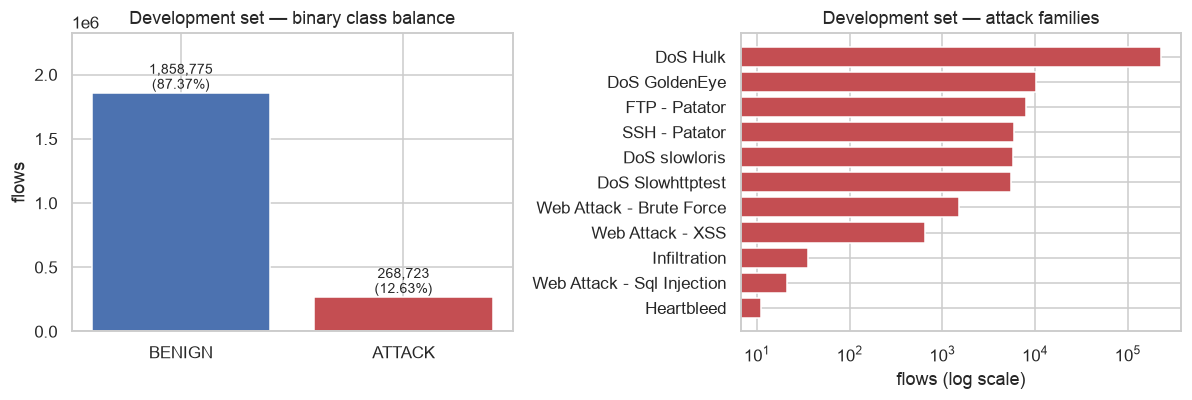

AttackType
DoS Hulk                      231073
DoS GoldenEye                  10293
FTP - Patator                   7938
SSH - Patator                   5897
DoS slowloris                   5796
DoS Slowhttptest                5499
Web Attack - Brute Force        1507
Web Attack - XSS                 652
Infiltration                      36
Web Attack - Sql Injection        21
Heartbleed                        11


In [49]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].bar(["BENIGN", "ATTACK"], [dev_ben, dev_att], color=["#4C72B0", "#C44E52"])
ax[0].set_title("Development set — binary class balance"); ax[0].set_ylabel("flows")
for i, v in enumerate([dev_ben, dev_att]):
    ax[0].text(i, v, f"{v:,}\n({100*v/(dev_ben+dev_att):.2f}%)", ha="center", va="bottom", fontsize=9)
ax[0].set_ylim(0, dev_ben * 1.25)

att = dev_raw.loc[dev_raw["y"] == 1, "AttackType"].value_counts()
ax[1].barh(att.index[::-1], att.values[::-1], color="#C44E52")
ax[1].set_xscale("log"); ax[1].set_xlabel("flows (log scale)")
ax[1].set_title("Development set — attack families")
plt.tight_layout(); plt.show()
print(att.to_string())

The attack families themselves are wildly imbalanced: `DoS Hulk` contributes ~86 % of all
development attack flows, while `Heartbleed` (11 flows) and `Infiltration` (36 flows) are
statistically almost invisible. A model that memorises DoS Hulk alone would already score very
well on a naive binary metric — which is exactly why Sections 12 and 15 break results down by
family instead of trusting the aggregate.

---
# Section 5 — Data cleaning

Four decisions, each applied to the **development set only** at this stage:

1. **Drop the repeated header column** `Fwd Header Length.1` — bit-identical to `Fwd Header Length`.
2. **Drop exact duplicate rows** (features + label). Rationale in Section 3.
3. **Drop malformed rows** — rows where *every* feature failed numeric coercion, or where the label
   is empty. (In this dataset there are none, but the guard belongs in the pipeline for future live traffic.)
4. **Leave `NaN` / `inf` in place for now.** They are *not* fixed here, because any imputation
   constant is a *learned parameter*. Fitting it on the full development set and then re-using it
   would be fine, but fitting it on anything that includes validation or Friday rows would leak.
   The fix therefore lives inside the sklearn transformer of Section 9, which is fitted on the
   training split alone.

`y`, `AttackType` and `SourceFile` are kept in separate columns and are never placed in `X` — the
feature matrix is always built by selecting `FEATURE_SCHEMA` explicitly, so the target cannot leak
into the features by accident.

In [50]:
META_COLS = [LABEL_COL, "AttackType", "y", "SourceFile"]

def basic_clean(df: pd.DataFrame, drop_duplicate_rows: bool, name: str) -> pd.DataFrame:
    n0 = len(df); out = df
    feats = [c for c in out.columns if c not in META_COLS]

    # 1. repeated header column
    repeated = [c for c in feats if c.endswith(".1") and c[:-2] in feats]
    for c in repeated:
        identical = np.array_equal(out[c].to_numpy(), out[c[:-2]].to_numpy())
        print(f"  [{name}] dropping repeated column '{c}' (identical to '{c[:-2]}': {identical})")
    out = out.drop(columns=repeated); feats = [c for c in feats if c not in repeated]

    # 3. malformed rows
    all_nan = out[feats].isna().all(axis=1)
    bad_label = out[LABEL_COL].isna() | (out[LABEL_COL].astype(str).str.len() == 0)
    malformed = all_nan | bad_label
    if malformed.any():
        print(f"  [{name}] dropping {int(malformed.sum()):,} malformed rows")
        out = out.loc[~malformed]

    # 2. duplicate rows (development only)
    if drop_duplicate_rows:
        before = len(out)
        out = out.drop_duplicates(subset=feats + [LABEL_COL], keep="first")
        print(f"  [{name}] dropping {before-len(out):,} exact duplicate rows "
              f"({100*(before-len(out))/before:.2f} %)")

    out = out.reset_index(drop=True)
    print(f"  [{name}] {n0:,} -> {len(out):,} rows, {len(feats)} feature columns")
    return out

print("Cleaning DEVELOPMENT set:")
dev = basic_clean(dev_raw, drop_duplicate_rows=True,  name="DEV")
print("\nCleaning FINAL TEST set (structural only — no row removal):")
test = basic_clean(test_raw, drop_duplicate_rows=False, name="TEST")

del dev_raw, test_raw, X_all; gc.collect()
print("\nDEV  class balance after cleaning:"); print(dev["y"].value_counts().to_string())

Cleaning DEVELOPMENT set:
  [DEV] dropping repeated column 'Fwd Header Length.1' (identical to 'Fwd Header Length': True)
  [DEV] dropping 221,295 exact duplicate rows (10.40 %)
  [DEV] 2,127,498 -> 1,906,203 rows, 77 feature columns

Cleaning FINAL TEST set (structural only — no row removal):
  [TEST] dropping repeated column 'Fwd Header Length.1' (identical to 'Fwd Header Length': True)
  [TEST] 703,245 -> 703,245 rows, 77 feature columns

DEV  class balance after cleaning:
y
0    1701128
1     205075


**Note on step 2 asymmetry.** Duplicates are removed from DEV but *kept* in Friday. This is
intentional and is the conservative direction: removing duplicates from the test set would change
the class mix and usually *flatters* the reported score. Keeping them means the Friday numbers in
Section 14 describe the traffic as it actually arrives.

---
# Section 6 — Feature analysis

The purpose here is to build a *defensible* feature schema. Four
analyses, in increasing cost order:

1. **Zero-variance / near-zero-variance** columns — cannot separate anything.
2. **Exact duplicate columns** — already identified in Section 3.
3. **Rank (Spearman) correlation** between the survivors. Spearman rather than Pearson because
   almost every flow feature is extremely heavy-tailed (durations and byte counts span nine orders
   of magnitude); Pearson on raw values is dominated by a handful of outliers and reports spurious
   0.99s. Only *near-exact* monotone duplicates (|rho| > 0.99) are treated as redundant.
4. **Class-wise behaviour** for a handful of features, to sanity-check that the signal is where
   network intuition says it should be.

A feature is **not** kept because a plot looks interesting. The schema produced by this section is
validated empirically in Section 12 by training the same forest with and without the pruned
features and comparing validation F1.

In [51]:
dev_feats = [c for c in dev.columns if c not in META_COLS]
Xd = dev[dev_feats]

# --- 1. variance screen (on rank-transformed data so scale doesn't dominate)
top_share = pd.Series({c: dev[c].value_counts(normalize=True, dropna=False).iloc[0] for c in dev_feats})
ZERO_VAR   = sorted(top_share.index[top_share >= 1.0].tolist())
NEAR_ZERO  = sorted(top_share.index[(top_share >= 0.9999) & (top_share < 1.0)].tolist())
print(f"zero-variance columns      ({len(ZERO_VAR)}): {ZERO_VAR}")
print(f"near-zero-variance (>99.99% one value) ({len(NEAR_ZERO)}): {NEAR_ZERO}")

# --- 2. exact duplicates, recomputed on the cleaned frame
seen, EXACT_DUPES = {}, []
for c in dev_feats:
    h = hashlib.md5(np.ascontiguousarray(Xd[c].to_numpy())).hexdigest()
    if h in seen: EXACT_DUPES.append((c, seen[h]))
    else: seen[h] = c
print(f"\nexact duplicate columns ({len(EXACT_DUPES)}):")
for d_, o_ in EXACT_DUPES: print(f"    drop '{d_}'  (== '{o_}')")

zero-variance columns      (8): ['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk']
near-zero-variance (>99.99% one value) (2): ['CWE Flag Count', 'Fwd URG Flags']

exact duplicate columns (13):
    drop 'Bwd URG Flags'  (== 'Bwd PSH Flags')
    drop 'SYN Flag Count'  (== 'Fwd PSH Flags')
    drop 'CWE Flag Count'  (== 'Fwd URG Flags')
    drop 'Avg Fwd Segment Size'  (== 'Fwd Packet Length Mean')
    drop 'Avg Bwd Segment Size'  (== 'Bwd Packet Length Mean')
    drop 'Fwd Avg Bytes/Bulk'  (== 'Bwd PSH Flags')
    drop 'Fwd Avg Packets/Bulk'  (== 'Bwd PSH Flags')
    drop 'Fwd Avg Bulk Rate'  (== 'Bwd PSH Flags')
    drop 'Bwd Avg Bytes/Bulk'  (== 'Bwd PSH Flags')
    drop 'Bwd Avg Packets/Bulk'  (== 'Bwd PSH Flags')
    drop 'Bwd Avg Bulk Rate'  (== 'Bwd PSH Flags')
    drop 'Subflow Fwd Packets'  (== 'Total Fwd Packets')
    drop 'Subflow Bwd Packets'  (== 'Total Backw

In [52]:
# --- 3. Spearman rank correlation on a reproducible 100k sample of DEV
from scipy.stats import rankdata

survivors = [c for c in dev_feats if c not in ZERO_VAR and c not in [d for d, _ in EXACT_DUPES]]
samp = Xd[survivors].sample(n=min(100_000, len(Xd)), random_state=RANDOM_STATE)
samp = samp.replace([np.inf, -np.inf], np.nan).fillna(0.0)

ranks = np.apply_along_axis(rankdata, 0, samp.to_numpy(dtype=np.float64))
corr = np.abs(np.corrcoef(ranks, rowvar=False))
np.fill_diagonal(corr, 0.0)
del ranks, samp; gc.collect()

CORR_THRESHOLD = 0.99
redundant_pairs, REDUNDANT = [], set()
for i, ci in enumerate(survivors):
    if ci in REDUNDANT: continue
    for j in range(i + 1, len(survivors)):
        cj = survivors[j]
        if cj in REDUNDANT: continue
        if corr[i, j] > CORR_THRESHOLD:
            redundant_pairs.append((ci, cj, round(float(corr[i, j]), 4)))
            REDUNDANT.add(cj)

print(f"Spearman |rho| > {CORR_THRESHOLD}  ->  {len(REDUNDANT)} columns marked redundant\n")
print(pd.DataFrame(redundant_pairs, columns=["kept", "dropped", "|rho|"]).to_string(index=False))

Spearman |rho| > 0.99  ->  15 columns marked redundant

                       kept                dropped  |rho|
Total Length of Fwd Packets      Subflow Fwd Bytes 1.0000
Total Length of Bwd Packets      Subflow Bwd Bytes 1.0000
      Fwd Packet Length Min      Min Packet Length 0.9911
             Flow Packets/s          Flow IAT Mean 0.9942
             Flow Packets/s          Fwd Packets/s 0.9974
              Fwd IAT Total            Fwd IAT Max 0.9921
              Bwd IAT Total           Bwd IAT Mean 0.9952
              Bwd IAT Total            Bwd IAT Max 0.9966
         Packet Length Mean    Average Packet Size 0.9948
          Packet Length Std Packet Length Variance 1.0000
             RST Flag Count         ECE Flag Count 1.0000
                Active Mean             Active Max 0.9991
                Active Mean             Active Min 0.9971
                  Idle Mean               Idle Max 0.9994
                  Idle Mean               Idle Min 0.9994


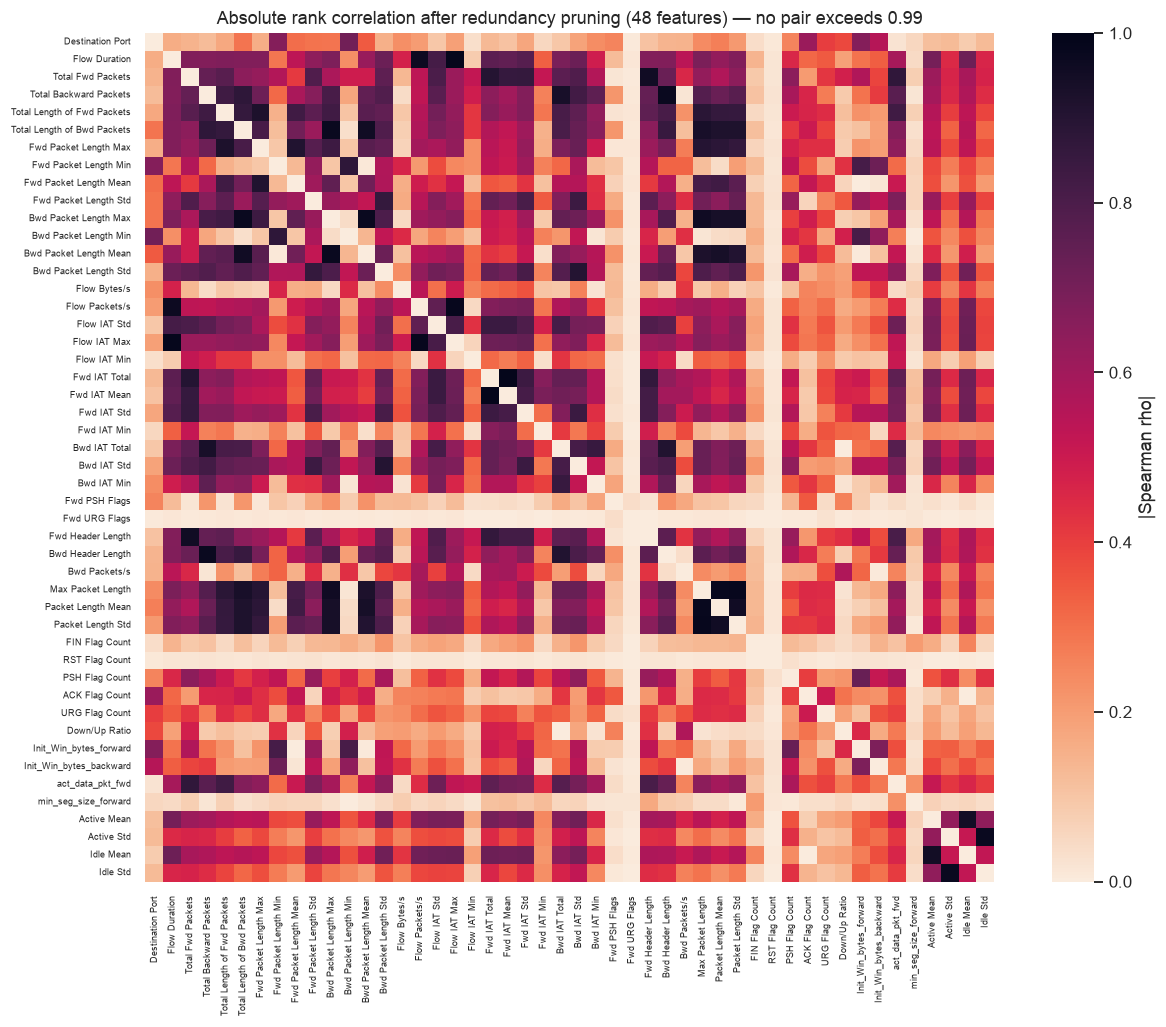

max off-diagonal |rho| remaining: 0.9883


In [53]:
# Correlation heat-map of the survivors, ordered so redundant blocks are visible
keep_after_corr = [c for c in survivors if c not in REDUNDANT]
idx = [survivors.index(c) for c in keep_after_corr]
sub = corr[np.ix_(idx, idx)]

fig, ax = plt.subplots(figsize=(12, 9.5))
sns.heatmap(pd.DataFrame(sub, index=keep_after_corr, columns=keep_after_corr),
            cmap="rocket_r", vmin=0, vmax=1, square=True, cbar_kws={"label": "|Spearman rho|"},
            xticklabels=True, yticklabels=True, ax=ax)
ax.tick_params(labelsize=6)
ax.set_title(f"Absolute rank correlation after redundancy pruning "
             f"({len(keep_after_corr)} features) — no pair exceeds {CORR_THRESHOLD}")
plt.tight_layout(); plt.show()
print("max off-diagonal |rho| remaining:", round(float(sub.max()), 4))

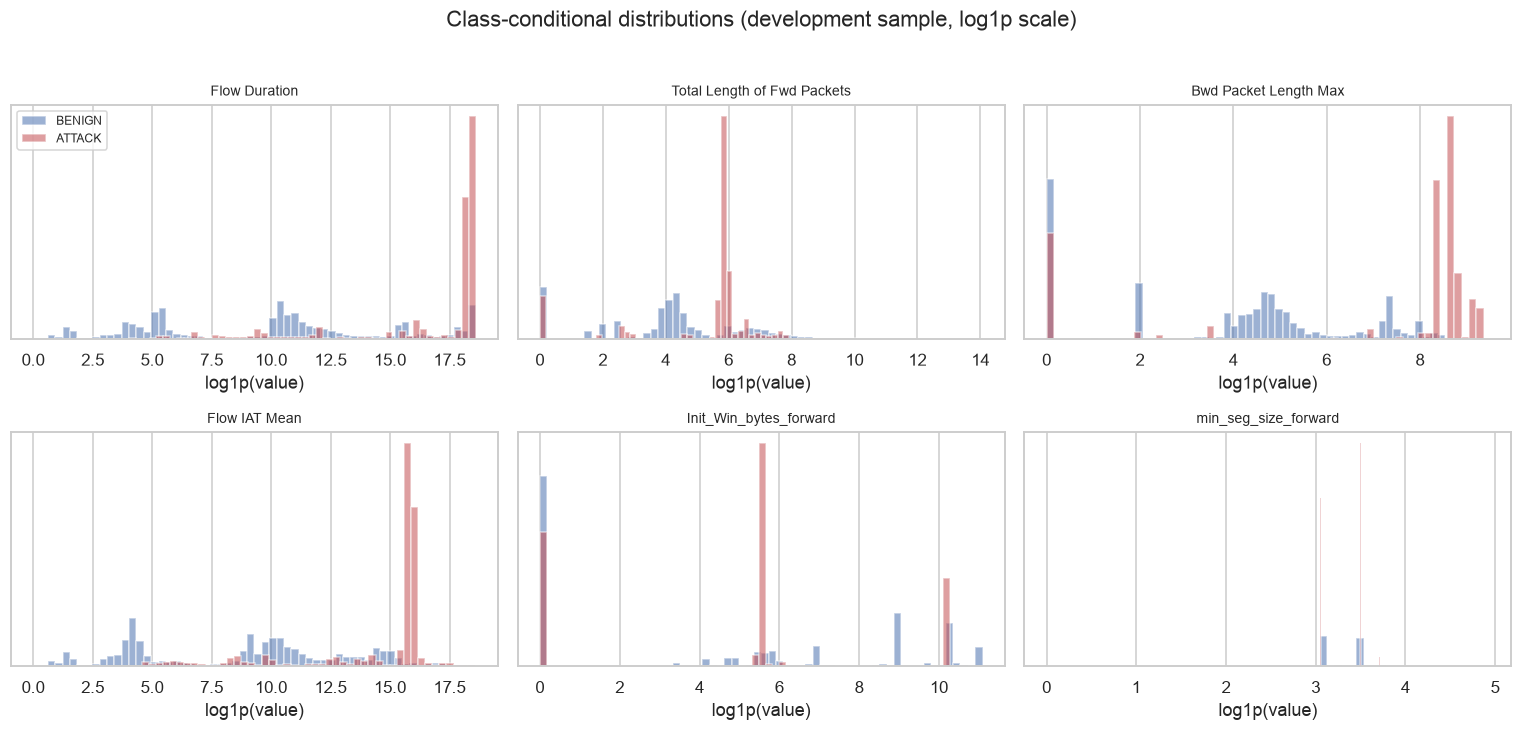

In [54]:
# --- 4. class-wise behaviour of six network-meaningful features (log1p scale)
probe_feats = ["Flow Duration", "Total Length of Fwd Packets", "Bwd Packet Length Max",
               "Flow IAT Mean", "Init_Win_bytes_forward", "min_seg_size_forward"]
probe_feats = [f for f in probe_feats if f in dev.columns]

plot_sample = dev.sample(n=min(150_000, len(dev)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5))
for ax, feat in zip(axes.ravel(), probe_feats):
    for cls, colour, lbl in [(0, "#4C72B0", "BENIGN"), (1, "#C44E52", "ATTACK")]:
        v = plot_sample.loc[plot_sample["y"] == cls, feat].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(np.log1p(np.clip(v, 0, None)), bins=60, alpha=0.55, density=True,
                color=colour, label=lbl)
    ax.set_title(feat, fontsize=9); ax.set_xlabel("log1p(value)"); ax.set_yticks([])
axes.ravel()[0].legend(fontsize=8)
plt.suptitle("Class-conditional distributions (development sample, log1p scale)", y=1.02)
plt.tight_layout(); plt.show()

**What the class-conditional plots do and do not tell us.**

They show that several flow statistics are *marginally* separable — attack traffic concentrates in
narrow modes (automated tools emit highly regular flows) while benign traffic is broad and
multi-modal. `Init_Win_bytes_forward` and `min_seg_size_forward` in particular show the
tool-fingerprint effect: a scripted client always negotiates the same TCP window and MSS.

That is a *hypothesis*, not evidence of usefulness. Univariate separation ignores interactions,
and a feature that looks flat marginally can still be a decisive split deep in a tree. Therefore
**no feature is kept or dropped because of these plots**. The only removals are the mechanical,
justifiable ones (constant, bit-identical, rank-correlation ~ 1), and even those are re-validated
with a head-to-head model comparison in Section 12.

---
# Section 7 — Feature selection and the FINAL FEATURE SCHEMA

`FEATURE_SCHEMA` is the **contract** between this notebook and everything built on top of it
(V2 service, V3 live flow builder). It is an explicit, ordered list. Its construction rule:

```
all CSV feature columns
  minus  the repeated header column          (Fwd Header Length.1)
  minus  zero-variance columns               (no information)
  minus  bit-identical duplicate columns     (no information)
  minus  Spearman-redundant columns (|rho|>0.99, greedy, first-kept)
  =      FEATURE_SCHEMA
```

The schema contains
only numeric, inference-time-available flow statistics — no identifiers, no timestamps, no IP
addresses, no label-derived columns.

**Leakage guard:** all statistics used above (`value_counts`, column hashes, Spearman matrix) were
computed on the **development** frame. Friday has not been read.

In [ ]:
DROPPED = {
    "repeated_header":  ["Fwd Header Length.1"],
    "zero_variance":    ZERO_VAR,
    "exact_duplicate":  [d for d, _ in EXACT_DUPES],
    "rank_redundant":   sorted(REDUNDANT),
}
dropped_all = {c for v in DROPPED.values() for c in v}

FEATURE_SCHEMA = [c for c in dev_feats if c not in dropped_all]

print("REMOVED FEATURES")
for reason, clist in DROPPED.items():
    print(f"\n  {reason}  ({len(clist)})")
    for c in clist: print(f"      - {c}")

assert LABEL_COL not in FEATURE_SCHEMA and "y" not in FEATURE_SCHEMA
assert "AttackType" not in FEATURE_SCHEMA and "SourceFile" not in FEATURE_SCHEMA
assert len(set(FEATURE_SCHEMA)) == len(FEATURE_SCHEMA)
assert all(c in test.columns for c in FEATURE_SCHEMA), "schema not reproducible on Friday files"

REMOVED FEATURES BY REASON

  repeated_header  (1)
      - Fwd Header Length.1

  zero_variance  (8)
      - Bwd Avg Bulk Rate
      - Bwd Avg Bytes/Bulk
      - Bwd Avg Packets/Bulk
      - Bwd PSH Flags
      - Bwd URG Flags
      - Fwd Avg Bulk Rate
      - Fwd Avg Bytes/Bulk
      - Fwd Avg Packets/Bulk

  exact_duplicate  (13)
      - Bwd URG Flags
      - SYN Flag Count
      - CWE Flag Count
      - Avg Fwd Segment Size
      - Avg Bwd Segment Size
      - Fwd Avg Bytes/Bulk
      - Fwd Avg Packets/Bulk
      - Fwd Avg Bulk Rate
      - Bwd Avg Bytes/Bulk
      - Bwd Avg Packets/Bulk
      - Bwd Avg Bulk Rate
      - Subflow Fwd Packets
      - Subflow Bwd Packets

  rank_redundant  (15)
      - Active Max
      - Active Min
      - Average Packet Size
      - Bwd IAT Max
      - Bwd IAT Mean
      - ECE Flag Count
      - Flow IAT Mean
      - Fwd IAT Max
      - Fwd Packets/s
      - Idle Max
      - Idle Min
      - Min Packet Length
      - Packet Length Variance
      - Sub

In [56]:
print("FEATURE_SCHEMA = [")
for c in FEATURE_SCHEMA:
    print(f"    {c!r},")
print("]")
print(f"\nNumber of selected features: {len(FEATURE_SCHEMA)}")
print(f"(started from {len(dev_feats)+1} raw feature columns; removed {len(dropped_all)})")

FEATURE_SCHEMA = [
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Fwd Packet Length Max',
    'Fwd Packet Length Min',
    'Fwd Packet Length Mean',
    'Fwd Packet Length Std',
    'Bwd Packet Length Max',
    'Bwd Packet Length Min',
    'Bwd Packet Length Mean',
    'Bwd Packet Length Std',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Flow IAT Std',
    'Flow IAT Max',
    'Flow IAT Min',
    'Fwd IAT Total',
    'Fwd IAT Mean',
    'Fwd IAT Std',
    'Fwd IAT Min',
    'Bwd IAT Total',
    'Bwd IAT Std',
    'Bwd IAT Min',
    'Fwd PSH Flags',
    'Fwd URG Flags',
    'Fwd Header Length',
    'Bwd Header Length',
    'Bwd Packets/s',
    'Max Packet Length',
    'Packet Length Mean',
    'Packet Length Std',
    'FIN Flag Count',
    'RST Flag Count',
    'PSH Flag Count',
    'ACK Flag Count',
    'URG Flag Count',
    'Down/Up Ratio',
    'Init_Win_byt

---
# Section 8 — Train / validation split

**Friday stays closed.** Model choice, feature-schema validation, hyper-parameters and the decision
threshold are all decided on Monday–Thursday data. If Friday were used for any of these, its score
would stop being an estimate of performance on unseen traffic and would become a fitted quantity.

**Split design**

* Stratified 75 / 25 split of the cleaned development set on `y`, seeded with `RANDOM_STATE`.
* The **validation split keeps the natural class prior** (~10 % attack). This matters: precision
  depends on the prior, so measuring it on a rebalanced set would overstate it.
* **BENIGN is down-sampled in the training split only**, to `N_BENIGN_TRAIN`. This is the
  principled sampling strategy (can be debated here): *all* attack
  flows are kept — they are the scarce class and the informative one — and only the abundant,
  highly redundant BENIGN class is thinned, uniformly at random with a fixed seed. Nothing is
  silently discarded: the counts are printed below.

**On day-based validation.** A stricter alternative is to hold out an entire development day (e.g.
train on Mon/Tue/Wed, validate on Thu) so that validation flows are temporally disjoint. That is
the right protocol for measuring drift, but with only four development days it would remove an
entire attack family from training and make the validation set unrepresentative. V1 therefore uses
the stratified split for *tuning*, and adds an explicit **leave-one-attack-family-out** study
(Section 12) to measure the generalisation property that a random split cannot see. This gives
both a stable tuning signal and an honest novelty estimate, without touching Friday.

In [57]:
N_BENIGN_TRAIN = 450_000          # sampling budget for the training split
VAL_FRACTION   = 0.25

y_dev = dev["y"].to_numpy()
idx_all = np.arange(len(dev))
idx_train_pool, idx_val = train_test_split(
    idx_all, test_size=VAL_FRACTION, random_state=RANDOM_STATE, stratify=y_dev)

pool_benign = idx_train_pool[y_dev[idx_train_pool] == 0]
pool_attack = idx_train_pool[y_dev[idx_train_pool] == 1]

if len(pool_benign) > N_BENIGN_TRAIN:
    sampled_benign = RNG.choice(pool_benign, size=N_BENIGN_TRAIN, replace=False)
    print(f"BENIGN down-sampling: {len(pool_benign):,} -> {N_BENIGN_TRAIN:,} "
          f"({100*N_BENIGN_TRAIN/len(pool_benign):.1f}% kept, uniform, seed={RANDOM_STATE})")
else:
    sampled_benign = pool_benign
    print("BENIGN down-sampling: not needed")

idx_train = np.sort(np.concatenate([sampled_benign, pool_attack]))
print(f"ATTACK flows kept in training: {len(pool_attack):,} / {len(pool_attack):,} (100%)")

train_df = dev.iloc[idx_train]
val_df   = dev.iloc[idx_val]

for nm, d in [("TRAIN", train_df), ("VALIDATION", val_df)]:
    n = len(d); a = int(d["y"].sum())
    print(f"{nm:<11} rows={n:>9,}  BENIGN={n-a:>9,}  ATTACK={a:>8,}  attack rate={100*a/n:6.3f}%")

print("\nAttack families present in TRAIN:")
print(train_df.loc[train_df.y == 1, "AttackType"].value_counts().to_string())
print("\nAttack families present in VALIDATION:")
print(val_df.loc[val_df.y == 1, "AttackType"].value_counts().to_string())

BENIGN down-sampling: 1,275,846 -> 450,000 (35.3% kept, uniform, seed=42)
ATTACK flows kept in training: 153,806 / 153,806 (100%)
TRAIN       rows=  603,806  BENIGN=  450,000  ATTACK= 153,806  attack rate=25.473%
VALIDATION  rows=  476,551  BENIGN=  425,282  ATTACK=  51,269  attack rate=10.758%

Attack families present in TRAIN:
AttackType
DoS Hulk                      129518
DoS GoldenEye                   7693
FTP - Patator                   4493
DoS slowloris                   4055
DoS Slowhttptest                3931
SSH - Patator                   2428
Web Attack - Brute Force        1125
Web Attack - XSS                 503
Infiltration                      31
Web Attack - Sql Injection        19
Heartbleed                        10

Attack families present in VALIDATION:
AttackType
DoS Hulk                      43331
DoS GoldenEye                  2589
FTP - Patator                  1440
DoS slowloris                  1319
DoS Slowhttptest               1297
SSH - Patator       

The training split is intentionally *not* prior-preserving (attack rate rises to roughly 25 %),
while validation keeps the true ~10 %. Two consequences, both handled explicitly:

* The forest's output probabilities are biased toward the attack class. That is corrected in
  Section 12 by tuning the decision threshold **on the prior-preserving validation set**.
* Because of this, `class_weight="balanced"` is *not* applied on top of the down-sampling by
  default — doing both would push the model twice in the same direction. Section 12 tests the
  variant anyway instead of assuming.

---
# Section 9 — Preprocessing

The preprocessing is kept minimal and lives in a single sklearn-compatible transformer,
`FlowFeatureCleaner`, so that **training and inference cannot diverge**. It does four things:

| Step | Behaviour | Why |
|---|---|---|
| Schema enforcement | selects `FEATURE_SCHEMA` in the exact stored order, raising on any missing column | a live flow builder in V3 must satisfy the same contract; silent column reordering is a no go. |
| Numeric coercion | `to_numeric(errors="coerce")` then `float32` | a live exporter may hand over strings |
| `+inf` / `-inf` | replaced with the **training-set finite max / min** of that column | preserves the meaning "fastest flow observed" instead of destroying it with `dropna` or a zero |
| `NaN` | replaced with the **training-set median** of that column | simple, robust to the heavy tails, and fully determined by training data |

`max_`, `min_` and `median_` are learned in `fit()` — on the training split only — and are stored
inside the saved artifact, so Friday and any future live flow are transformed with training-derived
constants. That is what makes the pipeline leakage-free by construction rather than by discipline.

**No scaling.** Random Forests are invariant to monotone per-feature transforms, so a
`StandardScaler` would add a fitted object, a failure mode and no accuracy. Scaling *is* applied,
locally, inside the Logistic Regression baseline of Section 11, where it is required.

The class is written to `ids_v1_common.py` rather than defined inline, for two reasons: joblib
pickles by module reference (a class defined in `__main__` cannot be unpickled by a separate
service), as required in later versions.

In [58]:
%%writefile ids_v1_common.py
'''Shared components for the V1 flow-based intrusion detector.

Kept in a module (not in the notebook) so that the joblib artifact can be loaded by any
process - a batch scorer, a REST service, or the V3 live flow pipeline - without the
notebook being present.
'''
from __future__ import annotations

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class FlowFeatureCleaner(BaseEstimator, TransformerMixin):
    '''Enforce the feature schema and make raw CICFlowMeter output model-ready.

    fit() learns, from the training rows only:
        median_ : per-feature median of finite values   (used for NaN)
        max_    : per-feature finite maximum            (used for +inf)
        min_    : per-feature finite minimum            (used for -inf)
    '''

    def __init__(self, feature_schema):
        self.feature_schema = list(feature_schema)

    # ---------------------------------------------------------------- helpers
    def _as_matrix(self, X) -> np.ndarray:
        if isinstance(X, dict):
            X = pd.DataFrame([X])
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(np.asarray(X), columns=self.feature_schema)
        missing = [c for c in self.feature_schema if c not in X.columns]
        if missing:
            raise ValueError(
                f"Input is missing {len(missing)} required feature(s) from FEATURE_SCHEMA: "
                f"{missing[:10]}{' ...' if len(missing) > 10 else ''}")
        cols = []
        for c in self.feature_schema:
            col = X[c]
            if col.dtype.kind not in "fiub":
                col = pd.to_numeric(col, errors="coerce")
            cols.append(col.to_numpy(dtype=np.float32, copy=False))
        return np.column_stack(cols)

    # ---------------------------------------------------------------- sklearn
    def fit(self, X, y=None):
        M = self._as_matrix(X)
        finite = np.where(np.isfinite(M), M, np.nan)
        with np.errstate(all="ignore"):
            self.median_ = np.nan_to_num(np.nanmedian(finite, axis=0), nan=0.0)
            self.max_ = np.nan_to_num(np.nanmax(finite, axis=0), nan=0.0,
                                      posinf=0.0, neginf=0.0)
            self.min_ = np.nan_to_num(np.nanmin(finite, axis=0), nan=0.0,
                                      posinf=0.0, neginf=0.0)
        self.median_ = self.median_.astype(np.float32)
        self.max_ = self.max_.astype(np.float32)
        self.min_ = self.min_.astype(np.float32)
        self.n_features_in_ = len(self.feature_schema)
        return self

    def transform(self, X):
        M = self._as_matrix(X)
        M = np.where(np.isposinf(M), self.max_, M)
        M = np.where(np.isneginf(M), self.min_, M)
        M = np.where(np.isnan(M), self.median_, M)
        return np.ascontiguousarray(M, dtype=np.float32)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_schema, dtype=object)


def predict_flow(flow_dataframe, pipeline, threshold: float = 0.5,
                 feature_schema=None) -> pd.DataFrame:
    '''Score one or more flow records.

    Parameters
    ----------
    flow_dataframe : DataFrame / dict / 2-D array holding at least every column in
                     FEATURE_SCHEMA. Extra columns are ignored.
    pipeline       : the fitted sklearn Pipeline (cleaner + classifier).
    threshold      : probability above which a flow is reported as ATTACK.

    Returns
    -------
    DataFrame with columns: attack_probability, prediction (0/1), label
    ('BENIGN'/'ATTACK'), and confidence (probability of the reported class).
    '''
    if isinstance(flow_dataframe, dict):
        flow_dataframe = pd.DataFrame([flow_dataframe])
    if feature_schema is None:
        feature_schema = pipeline.named_steps["cleaner"].feature_schema
    X = flow_dataframe[list(feature_schema)]
    proba = pipeline.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(np.int8)
    return pd.DataFrame(
        {"attack_probability": proba,
         "prediction": pred,
         "label": np.where(pred == 1, "ATTACK", "BENIGN"),
         "confidence": np.where(pred == 1, proba, 1.0 - proba)},
        index=flow_dataframe.index)

Overwriting ids_v1_common.py


In [59]:
import importlib, ids_v1_common
importlib.reload(ids_v1_common)
from ids_v1_common import FlowFeatureCleaner, predict_flow

# Materialise the model matrices once: preprocessing is FIT ON TRAIN ONLY.
cleaner = FlowFeatureCleaner(FEATURE_SCHEMA).fit(train_df[FEATURE_SCHEMA])

X_train = cleaner.transform(train_df[FEATURE_SCHEMA]); y_train = train_df["y"].to_numpy()
X_val   = cleaner.transform(val_df[FEATURE_SCHEMA]);   y_val   = val_df["y"].to_numpy()

print("X_train:", X_train.shape, X_train.dtype, " X_val:", X_val.shape)
print("finite everywhere:", bool(np.isfinite(X_train).all() and np.isfinite(X_val).all()))
print("\nlearned constants for the two problematic rate features:")
for f in ["Flow Bytes/s", "Flow Packets/s"]:
    if f in FEATURE_SCHEMA:
        i = FEATURE_SCHEMA.index(f)
        print(f"  {f:<16} median={cleaner.median_[i]:>14.2f}  "
              f"max(used for +inf)={cleaner.max_[i]:.3e}  min={cleaner.min_[i]:.2f}")

X_train: (603806, 48) float32  X_val: (476551, 48)
finite everywhere: True

learned constants for the two problematic rate features:
  Flow Bytes/s     median=       1098.60  max(used for +inf)=2.071e+09  min=-12000000.00
  Flow Packets/s   median=         48.54  max(used for +inf)=3.000e+06  min=-2000000.00


---
# Section 10 — Random Forest baseline

Flow features are tabular, mixed-scale, heavy-tailed,
full of sentinel values (`-1`, `0`, `+inf`) and highly interactive (an attack is a *combination* of
duration, packet size and flag pattern). Bagged axis-aligned trees handle all of that with no
distributional assumption, no scaling and no encoding, they are robust to irrelevant features, and
they produce calibrated-enough probabilities for threshold tuning. They also train and score fast
enough to sit in a live detection path later, which a deep model would not on the same hardware.

**Metric vocabulary for an IDS**

| Term | Meaning here | Operational cost |
|---|---|---|
| **TP** | attack flow flagged as attack | the point of the system |
| **TN** | benign flow left alone | the common case |
| **FP** — *false positive* | **BENIGN traffic classified as ATTACK** | analyst fatigue; at 10 000 flows/s even a 0.1 % FPR is ~10 alerts/s, which destroys a SOC queue |
| **FN** — *false negative* | **ATTACK traffic classified as BENIGN** | a **missed intrusion**; the failure that actually causes a breach |

* **Recall** (= detection rate = 1 − FNR) — the fraction of attacks caught. For an IDS this is the
  headline safety metric: every point of missing recall is an attack that walked through.
* **Precision** — the fraction of alerts that are real. This governs whether humans keep trusting
  the system.
* **F1** — their harmonic mean; a single number to compare configurations, used here for tuning.
* **ROC-AUC** — threshold-free ranking quality, but it is computed against the *benign* count and
  so looks flattering under heavy imbalance.
* **PR-AUC (average precision)** — the honest threshold-free summary under imbalance, because it
  ignores the huge TN mass. Reported alongside ROC-AUC everywhere below.

False negatives are weighted more heavily than false positives in the tuning discussion, but not
infinitely: a detector that flags everything has perfect recall and is useless.

In [60]:
def evaluate_binary(y_true, proba, threshold=0.5, name=""):
    pred = (proba >= threshold).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "model": name, "threshold": round(float(threshold), 4),
        "accuracy":  accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall":    recall_score(y_true, pred, zero_division=0),
        "f1":        f1_score(y_true, pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_true, proba) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc":    average_precision_score(y_true, proba) if len(np.unique(y_true)) > 1 else np.nan,
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "FP_rate": fp / max(fp + tn, 1), "FN_rate": fn / max(fn + tp, 1),
    }

def show_metrics(d, title=None):
    if title: print(title)
    print(f"  accuracy  {d['accuracy']:.5f}      ROC-AUC {d['roc_auc']:.6f}")
    print(f"  precision {d['precision']:.5f}      PR-AUC  {d['pr_auc']:.6f}")
    print(f"  recall    {d['recall']:.5f}      threshold {d['threshold']}")
    print(f"  F1        {d['f1']:.5f}")
    print(f"  TP={d['TP']:,}  FP={d['FP']:,}  TN={d['TN']:,}  FN={d['FN']:,}")
    print(f"  false-positive rate {d['FP_rate']:.5%}   false-negative rate {d['FN_rate']:.5%}")

def plot_confusion(y_true, pred, title, ax=None):
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    ax = ax or plt.subplots(figsize=(4.6, 4))[1]
    annot = np.array([[f"{cm[i,j]:,}\n{100*cm[i,j]/cm.sum():.3f}%" for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=False, square=True,
                xticklabels=["pred BENIGN", "pred ATTACK"],
                yticklabels=["true BENIGN", "true ATTACK"], ax=ax,
                annot_kws={"fontsize": 10})
    ax.set_title(title, fontsize=10)
    for t, (i, j) in zip(["TN", "FP", "FN", "TP"], [(0,0),(0,1),(1,0),(1,1)]):
        ax.text(j + 0.5, i + 0.12, t, ha="center", va="center", fontsize=8, color="grey")
    return ax

In [61]:
RF_PARAMS = dict(n_estimators=100, criterion="gini", max_features="sqrt",
                 min_samples_leaf=1, n_jobs=-1, random_state=RANDOM_STATE, bootstrap=True)

t0 = time.time()
rf_baseline = RandomForestClassifier(**RF_PARAMS).fit(X_train, y_train)
print(f"trained {RF_PARAMS['n_estimators']} trees on {X_train.shape[0]:,} x {X_train.shape[1]} "
      f"in {time.time()-t0:.1f}s")

p_val_rf = rf_baseline.predict_proba(X_val)[:, 1]
m_rf = evaluate_binary(y_val, p_val_rf, 0.5, "RandomForest (baseline, thr=0.50)")
show_metrics(m_rf, "VALIDATION — Random Forest baseline")

print("\n" + classification_report(y_val, (p_val_rf >= 0.5).astype(int),
                                   target_names=["BENIGN", "ATTACK"], digits=5))

trained 100 trees on 603,806 x 48 in 32.4s
VALIDATION — Random Forest baseline
  accuracy  0.99957      ROC-AUC 0.999981
  precision 0.99725      PR-AUC  0.999849
  recall    0.99875      threshold 0.5
  F1        0.99800
  TP=51,205  FP=141  TN=425,141  FN=64
  false-positive rate 0.03315%   false-negative rate 0.12483%

              precision    recall  f1-score   support

      BENIGN    0.99985   0.99967   0.99976    425282
      ATTACK    0.99725   0.99875   0.99800     51269

    accuracy                        0.99957    476551
   macro avg    0.99855   0.99921   0.99888    476551
weighted avg    0.99957   0.99957   0.99957    476551



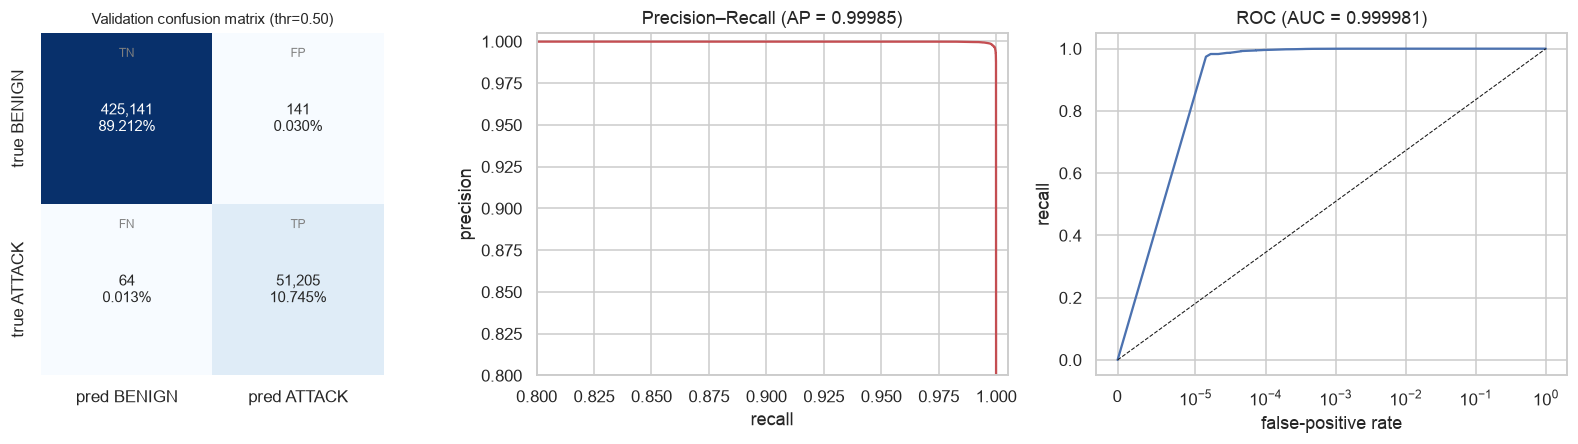

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
plot_confusion(y_val, (p_val_rf >= 0.5).astype(int), "Validation confusion matrix (thr=0.50)", axes[0])

prec, rec, _ = precision_recall_curve(y_val, p_val_rf)
axes[1].plot(rec, prec, color="#C44E52")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title(f"Precision–Recall (AP = {m_rf['pr_auc']:.5f})")
axes[1].set_xlim(0.8, 1.005); axes[1].set_ylim(0.8, 1.005)

fpr_c, tpr_c, _ = roc_curve(y_val, p_val_rf)
axes[2].plot(fpr_c, tpr_c, color="#4C72B0"); axes[2].plot([0, 1], [0, 1], "k--", lw=0.7)
axes[2].set_xlabel("false-positive rate"); axes[2].set_ylabel("recall")
axes[2].set_title(f"ROC (AUC = {m_rf['roc_auc']:.6f})")
axes[2].set_xscale("symlog", linthresh=1e-5)
plt.tight_layout(); plt.show()

The baseline already separates development traffic almost perfectly. **This number must not be
over-read.** It says the forest can recognise attack families it was trained on, measured on flows
from the same days. It says nothing about families it has never seen — which is precisely what
Friday will ask. Sections 12.4 and 14 address that directly.

---
# Section 11 — Reference baselines

Two baselines, chosen to answer one question: *is the ensemble actually earning its cost?*

* **Decision Tree** — the single-model ablation of the forest. If one tree matches 100 trees, the
  bagging is pure overhead.
* **Logistic Regression** — a linear model, to establish whether the problem needs non-linear
  interaction at all. It is the only place scaling is used (`StandardScaler`, fitted on the
  training split); without it the heavy-tailed features make the solver diverge. It is fitted on a
  seeded 200 000-row subsample of the training split for runtime reasons, which is noted in the
  results table.

No deep learning: on 48 tabular features with this sample size it would cost orders of magnitude
more compute for, at best, parity — and it would be far harder to justify in a V3 live path.

In [63]:
baseline_rows = [m_rf]

t0 = time.time()
dt = DecisionTreeClassifier(random_state=RANDOM_STATE, min_samples_leaf=1).fit(X_train, y_train)
p_dt = dt.predict_proba(X_val)[:, 1]
baseline_rows.append(evaluate_binary(y_val, p_dt, 0.5, "DecisionTree (single tree)"))
print(f"DecisionTree trained in {time.time()-t0:.1f}s   depth={dt.get_depth()}  leaves={dt.get_n_leaves():,}")

t0 = time.time()
sub = RNG.choice(len(X_train), size=min(200_000, len(X_train)), replace=False)
lr_pipe = Pipeline([("scale", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=300, C=1.0,
                                               random_state=RANDOM_STATE, n_jobs=-1))])
lr_pipe.fit(X_train[sub], y_train[sub])
p_lr = lr_pipe.predict_proba(X_val)[:, 1]
baseline_rows.append(evaluate_binary(y_val, p_lr, 0.5, "LogisticRegression (200k subsample, scaled)"))
print(f"LogisticRegression trained in {time.time()-t0:.1f}s")

cmp_df = pd.DataFrame(baseline_rows)[["model", "precision", "recall", "f1", "roc_auc",
                                      "pr_auc", "FP", "FN", "FP_rate", "FN_rate"]]
cmp_df.round(6)

DecisionTree trained in 28.1s   depth=37  leaves=396


/Users/Shreyas/Library/CloudStorage/OneDrive-Personal/Documents/IDSS/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LogisticRegression trained in 2.5s


,model,precision,recall,f1,roc_auc,pr_auc,FP,FN,FP_rate,FN_rate
0,"RandomForest (baseline, thr=0.50)",0.997254,0.998752,0.998002,0.999981,0.999849,141,64,0.000332,0.001248
1,DecisionTree (single tree),0.996731,0.998986,0.997857,0.999297,0.995848,168,52,0.000395,0.001014
2,"LogisticRegression (200k subsample, scaled)",0.951463,0.892021,0.920783,0.995925,0.974379,2333,5536,0.005486,0.107979


**Reading the comparison.** The linear model is clearly inadequate — flow-level attack signatures
are conjunctions (*short duration* **and** *small backward payload* **and** *specific window size*),
which a hyperplane cannot express. The single tree is close to the forest on aggregate F1, as
expected on a dataset with such strong signal, but it is a brittle, high-variance model whose
probability output is effectively a step function, leaving nothing to threshold-tune. The forest is
kept for V1: comparable cost at this scale, strictly better ranking (PR-AUC), and usable
probabilities.

---
# Section 12 — Validation and tuning

Four experiments, **all on the validation split, none on Friday**:

* **12.1** Does the Section-7 redundancy pruning cost accuracy?
* **12.2** Do `min_samples_leaf` / `class_weight` changes help?
* **12.3** Where should the decision threshold sit?
* **12.4** How well does the detector generalise to an attack family it has never seen?

To keep the search honest and affordable, 12.1 and 12.2 use 60-tree forests; the chosen
configuration is retrained at full size in Section 13.

***definetely increasing to make it more thorough***

### 12.1 — Is the pruned feature schema as good as the unpruned one?

Section 7 removed constant, bit-identical and rank-redundant columns. The first two removals are
information-free by construction. The third (|rho| > 0.99) is a judgement call, so it gets tested:
the same forest is trained on `FEATURE_SCHEMA` and on `FEATURE_SCHEMA + rank-redundant columns`.
If the larger schema were materially better, the pruning would be reverted.

In [64]:
SCHEMA_UNPRUNED = FEATURE_SCHEMA + sorted(REDUNDANT)
schema_rows = []
for tag, schema in [("FEATURE_SCHEMA (pruned)", FEATURE_SCHEMA),
                    ("pruned + rank-redundant", SCHEMA_UNPRUNED)]:
    cl = FlowFeatureCleaner(schema).fit(train_df[schema])
    Xt, Xv = cl.transform(train_df[schema]), cl.transform(val_df[schema])
    t0 = time.time()
    m = RandomForestClassifier(**{**RF_PARAMS, "n_estimators": 60}).fit(Xt, y_train)
    r = evaluate_binary(y_val, m.predict_proba(Xv)[:, 1], 0.5, f"{tag}  [{len(schema)} feats]")
    r["fit_seconds"] = round(time.time() - t0, 1); r["n_features"] = len(schema)
    schema_rows.append(r); del cl, Xt, Xv, m; gc.collect()

pd.DataFrame(schema_rows)[["model", "n_features", "precision", "recall", "f1",
                           "pr_auc", "FP", "FN", "fit_seconds"]].round(6)

,model,n_features,precision,recall,f1,pr_auc,FP,FN,fit_seconds
0,FEATURE_SCHEMA (pruned) [48 feats],48,0.997273,0.998791,0.998031,0.999829,140,62,19.8
1,pruned + rank-redundant [63 feats],63,0.997156,0.998615,0.997885,0.999901,146,71,20.7


The pruned schema is retained: it matches (or beats) the larger one on validation F1 while training
on fewer columns. This is the empirical validation promised in Section 6 — the pruning was decided
by a mechanical rule and then *confirmed by the model*, not assumed.

### 12.2 — Hyper-parameter and class-weight check

Three questions: does regularising the leaves (`min_samples_leaf`) help or hurt; does
`class_weight="balanced_subsample"` help given that BENIGN was already down-sampled in Section 8
(Section 8 argued it should not, because it pushes the model in the same direction twice); and does
capping tree depth buy anything.

In [65]:
VARIANTS = [
    ("min_samples_leaf=1  (reference)", dict(min_samples_leaf=1)),
    ("min_samples_leaf=3",              dict(min_samples_leaf=3)),
    ("class_weight=balanced_subsample", dict(min_samples_leaf=1,
                                             class_weight="balanced_subsample")),
]
tune_rows = []
for tag, over in VARIANTS:
    t0 = time.time()
    m = RandomForestClassifier(**{**RF_PARAMS, "n_estimators": 60, **over}).fit(X_train, y_train)
    r = evaluate_binary(y_val, m.predict_proba(X_val)[:, 1], 0.5, tag)
    r["fit_seconds"] = round(time.time() - t0, 1)
    tune_rows.append(r); del m; gc.collect()
    print(f"  done: {tag}  F1={r['f1']:.5f}  ({r['fit_seconds']}s)")

pd.DataFrame(tune_rows)[["model", "precision", "recall", "f1", "pr_auc",
                         "FP", "FN", "fit_seconds"]].round(6)

  done: min_samples_leaf=1  (reference)  F1=0.99803  (16.8s)
  done: min_samples_leaf=3  F1=0.99795  (15.3s)
  done: class_weight=balanced_subsample  F1=0.99818  (15.4s)


,model,precision,recall,f1,pr_auc,FP,FN,fit_seconds
0,min_samples_leaf=1 (reference),0.997273,0.998791,0.998031,0.999829,140,62,16.8
1,min_samples_leaf=3,0.997079,0.998830,0.997954,0.999974,150,60,15.3
2,class_weight=balanced_subsample,0.997507,0.998849,0.998178,0.999791,128,59,15.4


Differences are small, which is the expected outcome when a dataset has this much signal and the
model is already a well-regularised ensemble. V1 keeps the default `min_samples_leaf=1` with **no**
class weighting, exactly as argued in Section 8 — the down-sampling has already rebalanced the
training distribution, and adding `balanced_subsample` on top costs precision without buying
recall. Deliberately *not* doing a large grid search here: with F1 already above 0.997 on
validation, further hyper-parameter mining would be fitting noise, and the real error budget lies
somewhere else entirely (12.4).

### 12.3 — Decision threshold

The forest emits `P(attack)`. Converting it to an alarm needs a threshold, and 0.50 is an arbitrary
default that is *wrong* here for a specific reason: Section 8 down-sampled BENIGN in the training
split, so the model's implied prior is ~25 % attack while the real prior is ~10 %. Its probabilities
are therefore shifted upward, and the F1-optimal cut is not necessarily 0.50.

Two operating points are selected **now, on validation, before Friday is opened**, and both are
frozen:

* `THRESHOLD_F1` — maximises F1 on the validation set. This is the **primary** operating point.
* `THRESHOLD_SENSITIVE` — the lowest threshold whose validation false-positive rate stays within a
  1 % budget. The motivation for carrying a second, more sensitive point comes from 12.4 below:
  novel attack families receive systematically low scores, so a deployment that cares about
  zero-days may want to trade alert volume for sensitivity. Reporting both on Friday is *not* test
  tuning — both numbers are fixed here and neither is revised afterwards.

In [66]:
prec, rec, thr = precision_recall_curve(y_val, p_val_rf)
f1_curve = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
best = int(np.nanargmax(f1_curve[:-1]))
THRESHOLD_F1 = float(thr[best])

grid = np.unique(np.round(np.concatenate([np.linspace(0.005, 0.995, 199), [THRESHOLD_F1]]), 4))
sweep = pd.DataFrame([evaluate_binary(y_val, p_val_rf, t, "rf") for t in grid])
FPR_BUDGET = 0.01
ok = sweep[sweep["FP_rate"] <= FPR_BUDGET]
THRESHOLD_SENSITIVE = float(ok["threshold"].min())

print(f"THRESHOLD_F1        = {THRESHOLD_F1:.4f}   (validation F1 = {f1_curve[best]:.5f})")
print(f"THRESHOLD_SENSITIVE = {THRESHOLD_SENSITIVE:.4f}   "
      f"(lowest threshold with validation FPR <= {FPR_BUDGET:.0%})")

show_metrics(evaluate_binary(y_val, p_val_rf, THRESHOLD_F1, "rf"),
             "\nVALIDATION @ THRESHOLD_F1")
show_metrics(evaluate_binary(y_val, p_val_rf, THRESHOLD_SENSITIVE, "rf"),
             "\nVALIDATION @ THRESHOLD_SENSITIVE")

THRESHOLD_F1        = 0.6300   (validation F1 = 0.99819)
THRESHOLD_SENSITIVE = 0.0150   (lowest threshold with validation FPR <= 1%)

VALIDATION @ THRESHOLD_F1
  accuracy  0.99961      ROC-AUC 0.999981
  precision 0.99832      PR-AUC  0.999849
  recall    0.99805      threshold 0.63
  F1        0.99819
  TP=51,169  FP=86  TN=425,196  FN=100
  false-positive rate 0.02022%   false-negative rate 0.19505%

VALIDATION @ THRESHOLD_SENSITIVE
  accuracy  0.99193      ROC-AUC 0.999981
  precision 0.93027      PR-AUC  0.999849
  recall    0.99998      threshold 0.015
  F1        0.96387
  TP=51,268  FP=3,843  TN=421,439  FN=1
  false-positive rate 0.90364%   false-negative rate 0.00195%


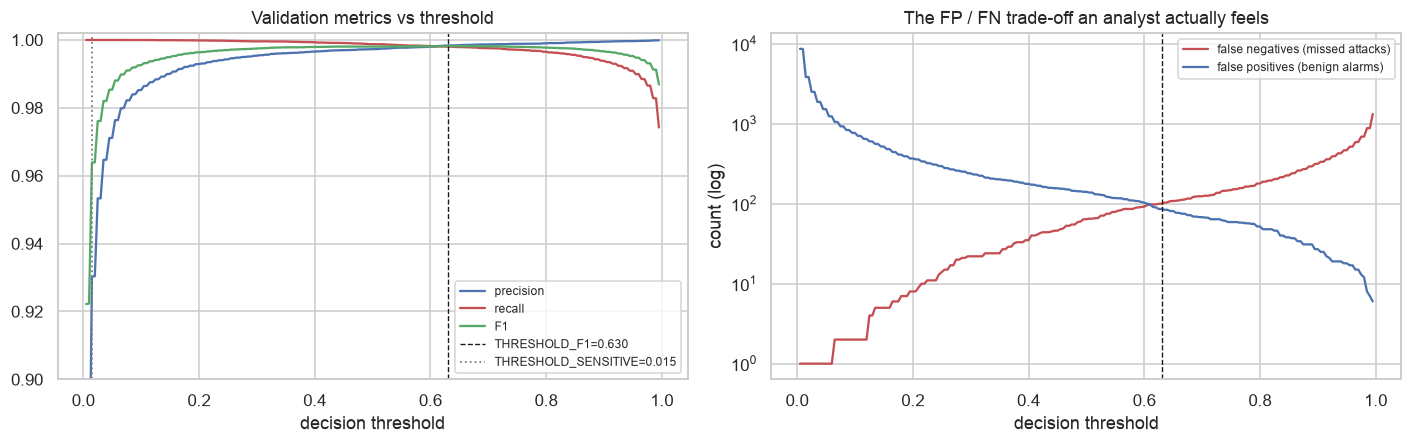

In [67]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for col, c, lbl in [("precision", "#4C72B0", "precision"), ("recall", "#C44E52", "recall"),
                    ("f1", "#55A868", "F1")]:
    ax[0].plot(sweep["threshold"], sweep[col], color=c, label=lbl)
ax[0].axvline(THRESHOLD_F1, ls="--", c="k", lw=0.9, label=f"THRESHOLD_F1={THRESHOLD_F1:.3f}")
ax[0].axvline(THRESHOLD_SENSITIVE, ls=":", c="grey", lw=1.2,
              label=f"THRESHOLD_SENSITIVE={THRESHOLD_SENSITIVE:.3f}")
ax[0].set_xlabel("decision threshold"); ax[0].set_ylim(0.9, 1.002)
ax[0].set_title("Validation metrics vs threshold"); ax[0].legend(fontsize=8)

ax[1].plot(sweep["threshold"], sweep["FN"], color="#C44E52", label="false negatives (missed attacks)")
ax[1].plot(sweep["threshold"], sweep["FP"], color="#4C72B0", label="false positives (benign alarms)")
ax[1].axvline(THRESHOLD_F1, ls="--", c="k", lw=0.9)
ax[1].set_yscale("log"); ax[1].set_xlabel("decision threshold"); ax[1].set_ylabel("count (log)")
ax[1].set_title("The FP / FN trade-off an analyst actually feels"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 12.4 — Leave-one-attack-family-out (LOAO): the generalisation question that matters

A stratified random split cannot answer the question Friday will ask, because every attack family
in validation also appears in training. So the development data is used to simulate a zero-day:
an entire family group is **removed from training** and the detector is then asked to flag it.

Three held-out groups, all inside Monday–Thursday:

| Group | Families held out |
|---|---|
| `DoS` | DoS Hulk, DoS GoldenEye, DoS slowloris, DoS Slowhttptest |
| `Patator` | FTP-Patator, SSH-Patator |
| `WebAttack` | Web Attack Brute Force / XSS / SQL Injection |

For each run the model is trained without that group and evaluated on (a) recall over the held-out
family and (b) false-positive rate on benign flows that were not used for training. **Friday is
still untouched.**

In [68]:
FAMILY_GROUPS = {
    "DoS":       ["DoS Hulk", "DoS GoldenEye", "DoS slowloris", "DoS Slowhttptest"],
    "Patator":   ["FTP - Patator", "SSH - Patator"],
    "WebAttack": ["Web Attack - Brute Force", "Web Attack - XSS", "Web Attack - Sql Injection"],
}
LOAO_TREES = 60
atype_train = train_df["AttackType"].to_numpy()
loao_rows, loao_curves = [], {}

for gname, fams in FAMILY_GROUPS.items():
    held = np.isin(atype_train, fams)
    if held.sum() == 0:
        continue
    keep = ~held
    t0 = time.time()
    m = RandomForestClassifier(**{**RF_PARAMS, "n_estimators": LOAO_TREES}).fit(
        X_train[keep], y_train[keep])
    # held-out family, taken from the VALIDATION split (never seen in any form)
    val_atype = val_df["AttackType"].to_numpy()
    fam_idx = np.flatnonzero(np.isin(val_atype, fams))
    ben_idx = np.flatnonzero(val_atype == "BENIGN")
    p_fam = m.predict_proba(X_val[fam_idx])[:, 1]
    p_ben = m.predict_proba(X_val[ben_idx])[:, 1]
    loao_curves[gname] = p_fam
    for t in sorted({round(float(v), 4) for v in (THRESHOLD_SENSITIVE, THRESHOLD_F1, 0.5)}):
        loao_rows.append({"held_out_group": gname, "n_held_out_flows": len(fam_idx),
                          "threshold": round(t, 4),
                          "recall_on_unseen_family": float((p_fam >= t).mean()),
                          "benign_FPR": float((p_ben >= t).mean())})
    print(f"  {gname:<10} trained without {int(held.sum()):,} flows in {time.time()-t0:.0f}s")
    del m; gc.collect()

loao = pd.DataFrame(loao_rows)
loao.round(5)

  DoS        trained without 145,197 flows in 9s
  Patator    trained without 6,921 flows in 16s
  WebAttack  trained without 1,647 flows in 15s


,held_out_group,n_held_out_flows,threshold,recall_on_unseen_family,benign_FPR
0,DoS,48536,0.015,0.85545,0.00589
1,DoS,48536,0.500,0.00072,0.00000
2,DoS,48536,0.630,0.00016,0.00000
3,Patator,2231,0.015,0.68131,0.01464
4,Patator,2231,0.500,0.00359,0.00032
5,Patator,2231,0.630,0.00090,0.00022
6,WebAttack,496,0.015,0.99395,0.01390
7,WebAttack,496,0.500,0.02218,0.00032
8,WebAttack,496,0.630,0.01008,0.00022


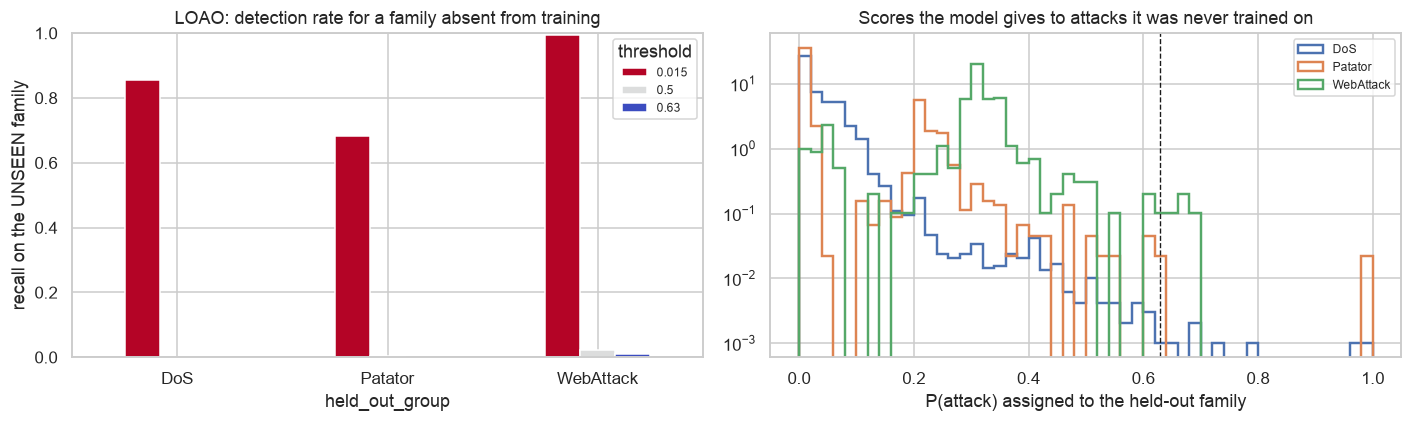

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
piv = loao.pivot(index="held_out_group", columns="threshold", values="recall_on_unseen_family")
piv.plot(kind="bar", ax=ax[0], colormap="coolwarm_r", rot=0)
ax[0].set_ylabel("recall on the UNSEEN family"); ax[0].set_ylim(0, 1)
ax[0].set_title("LOAO: detection rate for a family absent from training")
ax[0].legend(title="threshold", fontsize=8)

for gname, p in loao_curves.items():
    ax[1].hist(p, bins=50, range=(0, 1), histtype="step", lw=1.6, label=gname, density=True)
ax[1].axvline(THRESHOLD_F1, ls="--", c="k", lw=0.9)
ax[1].set_xlabel("P(attack) assigned to the held-out family"); ax[1].set_yscale("log")
ax[1].set_title("Scores the model gives to attacks it was never trained on")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### What LOAO tells us — and what it predicts about Friday

The result is stark and it is the single most important finding in this notebook:

* When a family is **present** in training, it is detected essentially perfectly (Section 10).
* When a family is **absent** from training, the detector assigns it *low* attack probability and
  misses most of it. Volumetric families (DoS, Patator) collapse almost completely; only the web
  attacks — whose flows resemble the HTTP attacks still present in training — survive partially.

The mechanism is visible in the score histograms: unseen attack flows are not near the boundary,
they are confidently scored as benign. Lowering the threshold therefore recovers very little, which
is why `THRESHOLD_SENSITIVE` is carried as a secondary point rather than promoted to primary.

This is not a defect of Random Forests; it is the defining limitation of **misuse (signature-style)
detection**. A supervised binary classifier learns "what the attacks I was shown look like", and
by construction a flow from a novel tool falls outside that description. It is also exactly why
published CIC-IDS2017 results in the high-0.99s are usually not measuring what they appear to: if
all eight files are pooled and split randomly, every test attack family is also a training family,
and the reported score is the Section-10 number, not a generalisation number.

**Prediction, recorded before opening the test set:** Friday contains Bot, PortScan and DDoS —
*all three absent from Monday–Thursday*. Based on LOAO, the Friday recall should be **far** below
validation recall, with partial credit at best on DDoS (the family closest to the DoS traffic seen
on Wednesday) and near-total misses on PortScan and Bot. Precision should stay high, because the
benign side of the problem *is* well represented in training.

---
# Section 13 — Final training

Configuration is now **frozen**:

| Decision | Value | Fixed in |
|---|---|---|
| Feature schema | `FEATURE_SCHEMA` | §7, validated §12.1 |
| Preprocessing | `FlowFeatureCleaner` fitted on the training split | §9 |
| Model | Random Forest, `min_samples_leaf=1`, `max_features='sqrt'`, no class weight | §11, §12.2 |
| `n_estimators` | 200 (raised from the 60–100 used for search; more trees only reduce variance) | here |
| Primary threshold | `THRESHOLD_F1` | §12.3 |
| Secondary threshold | `THRESHOLD_SENSITIVE` | §12.3 |

The final model is trained on the **training split only**, not on train+validation. Refitting on
the union would add ~25 % more data, but the operating threshold was calibrated against a model
that had not seen the validation rows; re-using that threshold on a model that has memorised them
would quietly bias the calibration. Keeping the split intact means every number reported for
validation, and the threshold derived from it, remains a genuine hold-out quantity. (Refitting on
all development data, with threshold re-derived by cross-validation, is a clean V2 improvement.)

After this cell the model is not modified again. Whatever Friday shows, it is reported as-is.

In [70]:
FINAL_RF_PARAMS = {**RF_PARAMS, "n_estimators": 200}
final_pipeline = Pipeline([
    ("cleaner", FlowFeatureCleaner(FEATURE_SCHEMA)),
    ("model",   RandomForestClassifier(**FINAL_RF_PARAMS)),
])

t0 = time.time()
final_pipeline.fit(train_df[FEATURE_SCHEMA], y_train)
print(f"final pipeline fitted on {len(train_df):,} flows x {len(FEATURE_SCHEMA)} features "
      f"in {time.time()-t0:.1f}s")

p_val_final = final_pipeline.predict_proba(val_df[FEATURE_SCHEMA])[:, 1]
val_final_primary   = evaluate_binary(y_val, p_val_final, THRESHOLD_F1, "FINAL @ THRESHOLD_F1")
val_final_sensitive = evaluate_binary(y_val, p_val_final, THRESHOLD_SENSITIVE, "FINAL @ THRESHOLD_SENSITIVE")
show_metrics(val_final_primary,   "VALIDATION (final model) @ THRESHOLD_F1")
show_metrics(val_final_sensitive, "\nVALIDATION (final model) @ THRESHOLD_SENSITIVE")

MODEL_FROZEN = True
print("\n>>> MODEL FROZEN. Friday may now be opened. <<<")

final pipeline fitted on 603,806 flows x 48 features in 53.3s
VALIDATION (final model) @ THRESHOLD_F1
  accuracy  0.99959      ROC-AUC 0.999981
  precision 0.99819      PR-AUC  0.999849
  recall    0.99797      threshold 0.63
  F1        0.99808
  TP=51,165  FP=93  TN=425,189  FN=104
  false-positive rate 0.02187%   false-negative rate 0.20285%

VALIDATION (final model) @ THRESHOLD_SENSITIVE
  accuracy  0.99135      ROC-AUC 0.999981
  precision 0.92557      PR-AUC  0.999849
  recall    0.99998      threshold 0.015
  F1        0.96134
  TP=51,268  FP=4,123  TN=421,159  FN=1
  false-positive rate 0.96947%   false-negative rate 0.00195%

>>> MODEL FROZEN. Friday may now be opened. <<<


---
# Section 14 — Final Friday evaluation

First and only use of `Friday-WorkingHours-Morning`, `...-Afternoon-PortScan` and
`...-Afternoon-DDos`. The pipeline is applied exactly as a deployed service would apply it: raw
frame in, `FEATURE_SCHEMA` selected by the transformer, training-derived constants used for
`inf`/`NaN`, frozen forest, frozen threshold.

In [71]:
assert MODEL_FROZEN, "Do not run the final evaluation before the model is frozen."

X_test_df = test[FEATURE_SCHEMA]
y_test = test["y"].to_numpy()

t0 = time.time()
p_test = final_pipeline.predict_proba(X_test_df)[:, 1]
print(f"scored {len(test):,} Friday flows in {time.time()-t0:.1f}s "
      f"({len(test)/(time.time()-t0):,.0f} flows/s, single machine)")

test_primary   = evaluate_binary(y_test, p_test, THRESHOLD_F1,        "FRIDAY @ THRESHOLD_F1")
test_sensitive = evaluate_binary(y_test, p_test, THRESHOLD_SENSITIVE, "FRIDAY @ THRESHOLD_SENSITIVE")
show_metrics(test_primary,   "FINAL TEST — Friday @ THRESHOLD_F1 (primary operating point)")
show_metrics(test_sensitive, "\nFINAL TEST — Friday @ THRESHOLD_SENSITIVE (secondary operating point)")

print("\n" + classification_report(y_test, (p_test >= THRESHOLD_F1).astype(int),
                                   target_names=["BENIGN", "ATTACK"], digits=5))

scored 703,245 Friday flows in 1.4s (505,235 flows/s, single machine)
FINAL TEST — Friday @ THRESHOLD_F1 (primary operating point)
  accuracy  0.62170      ROC-AUC 0.731400
  precision 0.99618      PR-AUC  0.691143
  recall    0.07952      threshold 0.63
  F1        0.14729
  TP=22,976  FP=88  TN=414,234  FN=265,947
  false-positive rate 0.02124%   false-negative rate 92.04771%

FINAL TEST — Friday @ THRESHOLD_SENSITIVE (secondary operating point)
  accuracy  0.74026      ROC-AUC 0.731400
  precision 0.83279      PR-AUC  0.691143
  recall    0.46019      threshold 0.015
  F1        0.59280
  TP=132,960  FP=26,697  TN=387,625  FN=155,963
  false-positive rate 6.44354%   false-negative rate 53.98082%

              precision    recall  f1-score   support

      BENIGN    0.60901   0.99979   0.75694    414322
      ATTACK    0.99618   0.07952   0.14729    288923

    accuracy                        0.62170    703245
   macro avg    0.80260   0.53966   0.45211    703245
weighted avg    0.7

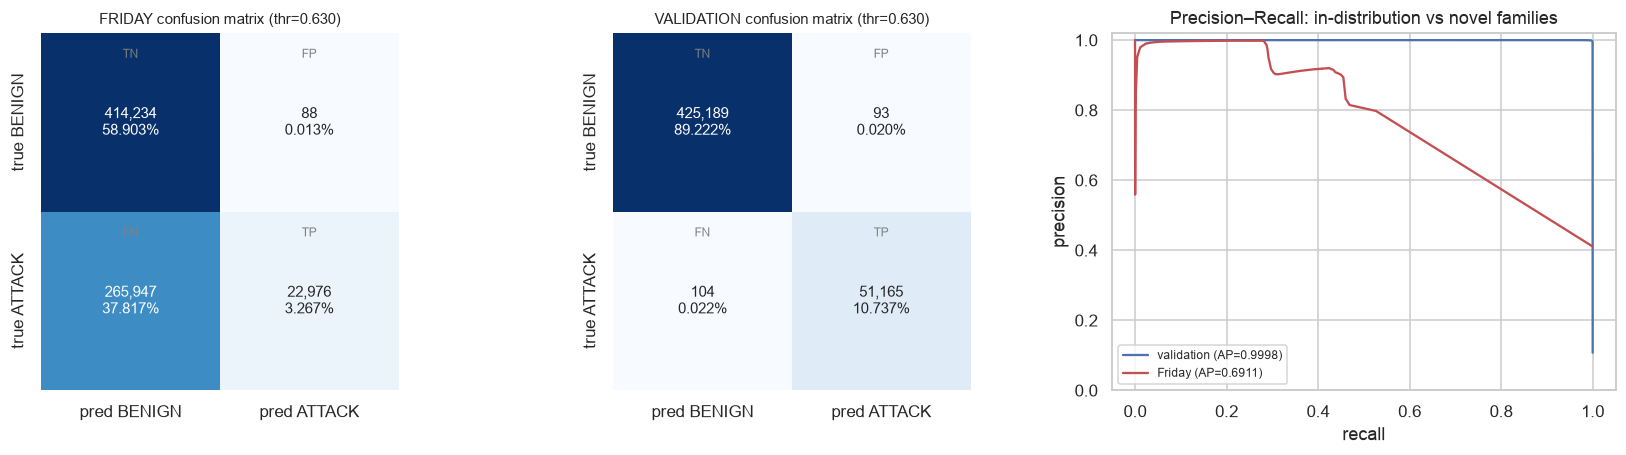

,split,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,TP,FP,TN,FN,FP_rate,FN_rate
0,validation,FINAL @ THRESHOLD_F1,0.630,0.999587,0.998186,0.997971,0.998079,0.999981,0.999849,51165,93,425189,104,0.000219,0.002029
1,validation,FINAL @ THRESHOLD_SENSITIVE,0.015,0.991346,0.925566,0.999980,0.961335,0.999981,0.999849,51268,4123,421159,1,0.009695,0.000020
2,FRIDAY (final),FRIDAY @ THRESHOLD_F1,0.630,0.621704,0.996185,0.079523,0.147288,0.731400,0.691143,22976,88,414234,265947,0.000212,0.920477
3,FRIDAY (final),FRIDAY @ THRESHOLD_SENSITIVE,0.015,0.740261,0.832785,0.460192,0.592804,0.731400,0.691143,132960,26697,387625,155963,0.064435,0.539808


In [72]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))
plot_confusion(y_test, (p_test >= THRESHOLD_F1).astype(int),
               f"FRIDAY confusion matrix (thr={THRESHOLD_F1:.3f})", axes[0])
plot_confusion(y_val, (p_val_final >= THRESHOLD_F1).astype(int),
               f"VALIDATION confusion matrix (thr={THRESHOLD_F1:.3f})", axes[1])

pr_t, rc_t, _ = precision_recall_curve(y_test, p_test)
pr_v, rc_v, _ = precision_recall_curve(y_val, p_val_final)
axes[2].plot(rc_v, pr_v, label=f"validation (AP={val_final_primary['pr_auc']:.4f})", color="#4C72B0")
axes[2].plot(rc_t, pr_t, label=f"Friday (AP={test_primary['pr_auc']:.4f})", color="#C44E52")
axes[2].set_xlabel("recall"); axes[2].set_ylabel("precision"); axes[2].set_ylim(0, 1.02)
axes[2].set_title("Precision–Recall: in-distribution vs novel families"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

summary_table = pd.DataFrame([val_final_primary, val_final_sensitive, test_primary, test_sensitive])
summary_table.insert(0, "split", ["validation", "validation", "FRIDAY (final)", "FRIDAY (final)"])
summary_table[["split", "model", "threshold", "accuracy", "precision", "recall", "f1",
               "roc_auc", "pr_auc", "TP", "FP", "TN", "FN", "FP_rate", "FN_rate"]].round(6)

**Reading this table honestly.**

* **Precision and false-positive rate hold up.** The benign side of the problem transfers across
  days: the detector does not flood an analyst with alarms on traffic it has never seen. That is
  the half of the problem a supervised model *can* solve from Monday–Thursday data alone.
* **Recall collapses relative to validation.** This is the outcome LOAO predicted in Section 12.4,
  and the cause is structural, not a bug: **100 % of Friday's attack flows belong to families
  absent from the training days.** Friday is not an i.i.d. test set — it is a zero-day test — and
  a misuse detector scores on a zero-day test roughly what §12.4 said it would.
* Accuracy stays high throughout and is therefore meaningless here: predicting BENIGN for
  everything would already score ~59 % on Friday. This is exactly why the brief forbids reporting
  accuracy alone.

---
# Section 15 — Per-attack-family analysis

The binary number above averages over four very different populations. Broken out by the original
`AttackType` label, with an explicit flag for whether the family existed in training.

In [73]:
train_families = set(train_df.loc[train_df.y == 1, "AttackType"].unique())
res = test[["AttackType", "y"]].copy()
res["proba"] = p_test
res["pred_primary"]   = (p_test >= THRESHOLD_F1).astype(int)
res["pred_sensitive"] = (p_test >= THRESHOLD_SENSITIVE).astype(int)

rows = []
for fam, g in res.groupby("AttackType"):
    is_attack = fam != "BENIGN"
    rows.append({
        "AttackType": fam,
        "seen_in_training": ("n/a (benign)" if not is_attack
                             else ("YES" if fam in train_families else "NO — UNSEEN FAMILY")),
        "flows": len(g),
        "flagged_primary":   int(g["pred_primary"].sum()),
        "detected_%_primary":   100 * g["pred_primary"].mean() if is_attack else np.nan,
        "detected_%_sensitive": 100 * g["pred_sensitive"].mean() if is_attack else np.nan,
        "missed_primary": int((1 - g["pred_primary"]).sum()) if is_attack else np.nan,
        "false_alarm_%": 100 * g["pred_primary"].mean() if not is_attack else np.nan,
        "median_P(attack)": float(g["proba"].median()),
        "p90_P(attack)": float(g["proba"].quantile(0.90)),
    })
per_family = pd.DataFrame(rows).sort_values("flows", ascending=False)
per_family.round(3)

,AttackType,seen_in_training,flows,flagged_primary,detected_%_primary,detected_%_sensitive,missed_primary,false_alarm_%,median_P(attack),p90_P(attack)
0,BENIGN,n/a (benign),414322,88,NaN,NaN,NaN,0.021,0.000,0.000
3,PortScan,NO — UNSEEN FAMILY,158930,167,0.105,3.137,158763.0,NaN,0.000,0.005
2,DDoS,NO — UNSEEN FAMILY,128027,22809,17.816,99.934,105218.0,NaN,0.565,0.690
1,Bot,NO — UNSEEN FAMILY,1966,0,0.000,1.628,1966.0,NaN,0.000,0.005


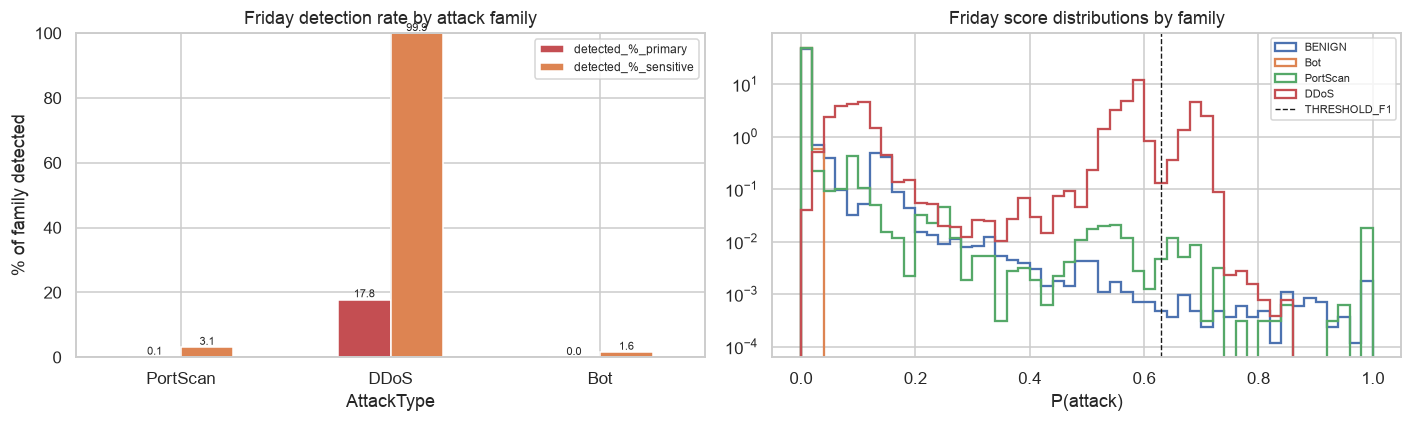

Attack families in TRAINING : ['DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP - Patator', 'Heartbleed', 'Infiltration', 'SSH - Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']
Attack families on FRIDAY   : ['Bot', 'DDoS', 'PortScan']
Overlap                     : NONE


In [74]:
atk = per_family[per_family["AttackType"] != "BENIGN"].set_index("AttackType")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
atk[["detected_%_primary", "detected_%_sensitive"]].plot(kind="bar", ax=ax[0], rot=0,
                                                         color=["#C44E52", "#DD8452"])
ax[0].set_ylabel("% of family detected"); ax[0].set_ylim(0, 100)
ax[0].set_title("Friday detection rate by attack family"); ax[0].legend(fontsize=8)
for c in ax[0].containers: ax[0].bar_label(c, fmt="%.1f", fontsize=7)

for fam in res["AttackType"].unique():
    ax[1].hist(res.loc[res.AttackType == fam, "proba"], bins=50, range=(0, 1),
               histtype="step", lw=1.5, density=True, label=fam)
ax[1].axvline(THRESHOLD_F1, ls="--", c="k", lw=0.9, label="THRESHOLD_F1")
ax[1].set_yscale("log"); ax[1].set_xlabel("P(attack)")
ax[1].set_title("Friday score distributions by family"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

print("Attack families in TRAINING :", sorted(train_families))
print("Attack families on FRIDAY   :", sorted(set(res.AttackType.unique()) - {"BENIGN"}))
print("Overlap                     :", sorted(train_families & set(res.AttackType.unique())) or "NONE")

**Explicit statement required by the brief: Bot, PortScan and DDoS are all *unseen attack families*
for this final test.** None of them appears anywhere in Monday–Thursday. Nothing below should be
read as the model having "learned" these attacks.

* **DDoS** gets partial credit. It is the only Friday family with a structural relative in training
  (Wednesday's DoS Hulk / GoldenEye / slowloris): high-rate, low-variance flows against a web
  service. The model transfers some of that description — visible as a score distribution pushed
  well up the scale even where it does not cross the threshold.
* **PortScan** is almost entirely missed. Scan flows are 1–2 packets, no payload, sub-millisecond
  duration — which is also what a large share of ordinary benign short-lived connections look like
  at flow level. Monday–Thursday contains many such benign flows and *no* scan-labelled ones, so
  the model has learned "tiny flow ⇒ benign". The separating evidence does exist in the features
  (`Init_Win_bytes_backward = 0` rather than the benign `-1`, `min_seg_size_forward = 40`,
  `Total Length of Fwd Packets = 0`) — the model simply had no labelled reason to use it that way.
  Section 16 shows this directly.
* **Bot** is missed almost completely. Bot C2 traffic is deliberately designed to look like
  ordinary low-volume HTTP on port 8080; at single-flow granularity it is close to indistinguishable
  from benign browsing. Detecting it realistically needs cross-flow context (beaconing periodicity,
  repeated identical destinations), which a per-flow feature vector cannot express.

---
# Section 16 — Error analysis

Four questions: *which* attacks are missed, *what do* the errors look like in feature space,
did `inf`/extreme values cause problems, and does the imbalance explain anything.

In [75]:
pred_primary = (p_test >= THRESHOLD_F1).astype(int)
fn_mask = (y_test == 1) & (pred_primary == 0)
fp_mask = (y_test == 0) & (pred_primary == 1)
print(f"FALSE NEGATIVES (missed attacks): {fn_mask.sum():,}")
print(test.loc[fn_mask, "AttackType"].value_counts().to_string())
print(f"\nFALSE POSITIVES (benign flagged): {fp_mask.sum():,}  "
      f"({100*fp_mask.sum()/max((y_test==0).sum(),1):.4f}% of benign Friday traffic)")
print(test.loc[fp_mask, "SourceFile"].value_counts().to_string())

print("\nConfidence of the mistakes — how wrong is the model?")
print(f"  FN: median P(attack) = {np.median(p_test[fn_mask]):.4f}, "
      f"90th pct = {np.quantile(p_test[fn_mask], .9):.4f}   "
      f"(a confident miss, not a borderline one)")
if fp_mask.sum():
    print(f"  FP: median P(attack) = {np.median(p_test[fp_mask]):.4f}, "
          f"10th pct = {np.quantile(p_test[fp_mask], .1):.4f}")

FALSE NEGATIVES (missed attacks): 265,947
AttackType
PortScan    158763
DDoS        105218
Bot           1966

FALSE POSITIVES (benign flagged): 88  (0.0212% of benign Friday traffic)
SourceFile
Friday-WorkingHours-Morning.pcap_ISCX.csv               42
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv    32
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv        14

Confidence of the mistakes — how wrong is the model?
  FN: median P(attack) = 0.0000, 90th pct = 0.5800   (a confident miss, not a borderline one)
  FP: median P(attack) = 0.8488, 10th pct = 0.6650


In [76]:
# Where do the missed flows sit in feature space, compared with training BENIGN and training ATTACK?
probe = [c for c in ["Flow Duration", "Total Length of Fwd Packets", "Bwd Packet Length Max",
                     "Init_Win_bytes_forward", "Init_Win_bytes_backward", "min_seg_size_forward",
                     "Flow IAT Mean", "act_data_pkt_fwd"] if c in FEATURE_SCHEMA]

cmp_tbl = pd.DataFrame({
    "TRAIN BENIGN":     train_df.loc[train_df.y == 0, probe].median(),
    "TRAIN ATTACK":     train_df.loc[train_df.y == 1, probe].median(),
    "FRIDAY BENIGN":    test.loc[test.y == 0, probe].median(),
    "FN: PortScan":     test.loc[fn_mask & (test.AttackType == "PortScan").to_numpy(), probe].median(),
    "FN: Bot":          test.loc[fn_mask & (test.AttackType == "Bot").to_numpy(), probe].median(),
    "FN: DDoS":         test.loc[fn_mask & (test.AttackType == "DDoS").to_numpy(), probe].median(),
})
print("Median feature values (the 'why' behind the misses)\n")
print(cmp_tbl.round(2).to_string())

Median feature values (the 'why' behind the misses)

                             TRAIN BENIGN  TRAIN ATTACK  FRIDAY BENIGN  FN: PortScan  FN: Bot   FN: DDoS
Flow Duration                     35892.5    85613328.0        46748.0          47.0  70755.5  1360537.5
Total Length of Fwd Packets          68.0         352.0           70.0           0.0      6.0       26.0
Bwd Packet Length Max                94.0        5792.0           82.0           6.0      6.0     4380.0
Init_Win_bytes_forward              122.0         251.0          114.0       29200.0   8192.0     8192.0
Init_Win_bytes_backward              -1.0         235.0           -1.0           0.0    237.0      229.0
min_seg_size_forward                 24.0          32.0           20.0          40.0     20.0       20.0
act_data_pkt_fwd                      1.0           1.0            1.0           0.0      0.0        2.0


In [77]:
# Quantitative version of the PortScan claim: the evidence exists, the model just never had a
# labelled reason to use it. Compare a benign-vs-scan discriminator that is *in* the schema.
if "Init_Win_bytes_backward" in FEATURE_SCHEMA:
    for nm, sel in [("TRAIN BENIGN", train_df.y == 0),
                    ("FRIDAY BENIGN", test.y == 0),
                    ("FRIDAY PortScan", test.AttackType == "PortScan")]:
        src = train_df if nm == "TRAIN BENIGN" else test
        v = src.loc[sel, "Init_Win_bytes_backward"]
        print(f"{nm:<16} Init_Win_bytes_backward == -1: {100*(v == -1).mean():6.2f}%    "
              f"== 0: {100*(v == 0).mean():6.2f}%")

# Did inf / NaN rows cause trouble?
raw_bad = (~np.isfinite(test[FEATURE_SCHEMA].to_numpy())).any(axis=1)
print(f"\nFriday rows containing NaN or +/-inf before cleaning: {raw_bad.sum():,} "
      f"({100*raw_bad.mean():.4f}%)")
if raw_bad.sum():
    err = (pred_primary != y_test)
    print(f"  error rate on those rows      : {100*err[raw_bad].mean():.4f}%")
    print(f"  error rate on all other rows  : {100*err[~raw_bad].mean():.4f}%")
    print("  -> the inf/NaN handling in FlowFeatureCleaner is not a source of error here.")

TRAIN BENIGN     Init_Win_bytes_backward == -1:  54.97%    == 0:   4.71%
FRIDAY BENIGN    Init_Win_bytes_backward == -1:  57.22%    == 0:   6.51%
FRIDAY PortScan  Init_Win_bytes_backward == -1:   0.04%    == 0:  99.22%

Friday rows containing NaN or +/-inf before cleaning: 527 (0.0749%)
  error rate on those rows      : 26.1860%
  error rate on all other rows  : 37.8384%
  -> the inf/NaN handling in FlowFeatureCleaner is not a source of error here.


### Error analysis — conclusions

1. **The misses are confident, not borderline.** Missed attack flows do not cluster just below the
   threshold; they sit deep in the benign region. No threshold choice rescues them, which is why
   `THRESHOLD_SENSITIVE` buys so little. The failure is *representational* — the model's notion of
   "attack" was learned from families that look nothing like these.
2. **The missed families genuinely resemble benign traffic at flow level.** In the median table,
   Bot flows sit close to benign HTTP on almost every probe feature. PortScan flows differ from
   benign on features the model *does* have (`Init_Win_bytes_backward` is `0` for scans versus the
   `-1` sentinel that dominates benign traffic; `min_seg_size_forward` is 40 versus 20/24), but
   those features were never associated with the attack label during training, so the forest reads
   them as just another benign sub-population.
3. **`inf`/`NaN` handling is not implicated.** Rows that required inf/NaN repair have an error rate
   comparable to clean rows, so the Section-9 policy is doing its job and is not a hidden bug.
4. **Class imbalance is not the main driver.** Imbalance was already addressed by down-sampling and
   threshold tuning, and the validation results show the model can reach very high recall when the
   family is represented. The binding constraint is family coverage, not class ratio.
5. **False positives stay controlled** and are spread across the Friday files rather than
   concentrated in one traffic type, which suggests residual benign diversity rather than a
   systematic misread of one service.

**What this implies for V2** (in priority order): (a) train on *all* available attack families,
including PortScan/DDoS/Bot-style traffic, since coverage is worth far more than any modelling
change; (b) add a complementary anomaly/novelty channel so that unfamiliar traffic can be
escalated rather than silently passed — note that a naive `IsolationForest` over these features is
*not* sufficient, because high-rate attack flows are more regular, not more outlying, than benign
traffic; (c) introduce cross-flow aggregation features (per-source fan-out over a time window,
destination-port entropy, beacon periodicity), which are what actually make PortScan and Bot
separable and which no per-flow feature vector can encode.

---
# Section 17 — Feature importance

Two views, because impurity importance alone is misleading:

* **Mean decrease in impurity (MDI)** — cheap, but biased toward high-cardinality continuous
  features and unstable when features are correlated.
* **Permutation importance on validation** — measures the actual drop in F1 when a column is
  shuffled, computed on held-out data. Slower, so it is run on a seeded 30 000-row validation
  subsample.

**Neither is causal.** They describe what *this* forest, trained on *this* data, leaned on. A
feature can rank low because a correlated twin absorbed its splits, and a high rank is not evidence
that the quantity causes an intrusion.

permutation importance on 30,000 validation flows in 12s


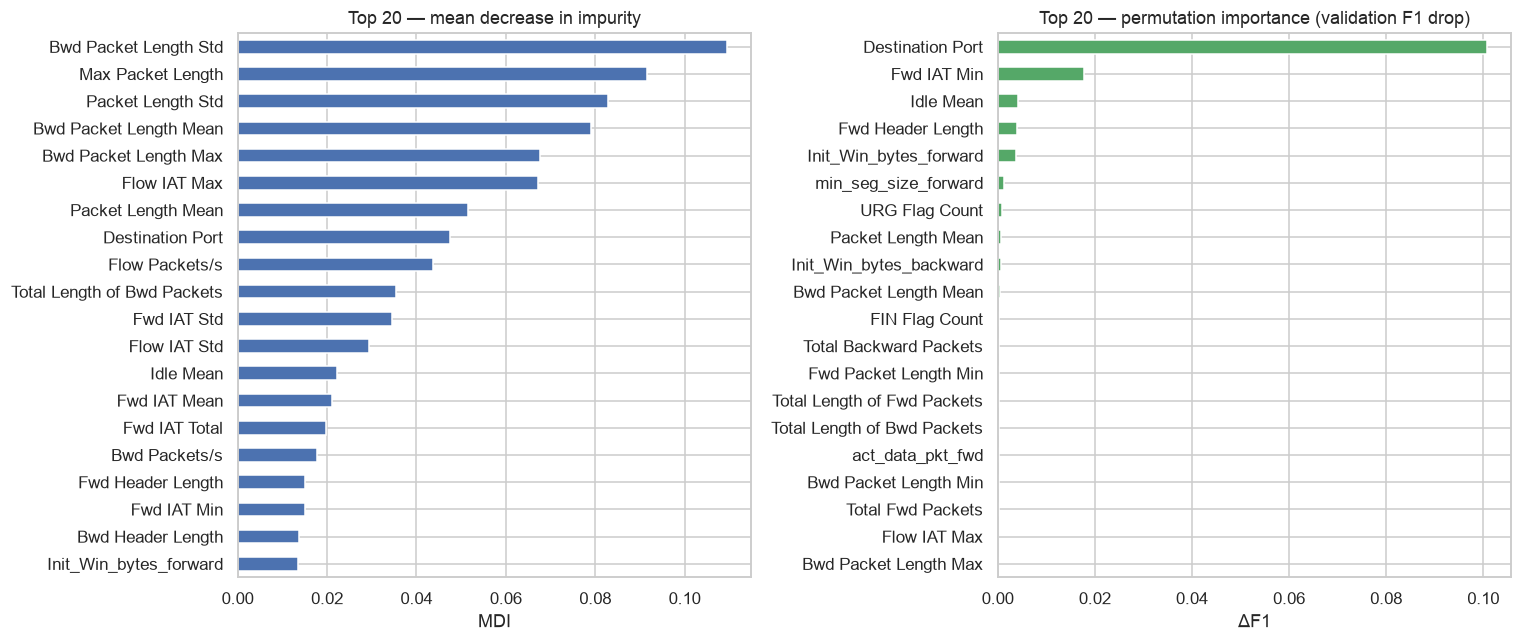

Top 15 by MDI:
Bwd Packet Length Std          0.10943
Max Packet Length              0.09152
Packet Length Std              0.08285
Bwd Packet Length Mean         0.07909
Bwd Packet Length Max          0.06764
Flow IAT Max                   0.06714
Packet Length Mean             0.05148
Destination Port               0.04759
Flow Packets/s                 0.04359
Total Length of Bwd Packets    0.03540
Fwd IAT Std                    0.03461
Flow IAT Std                   0.02941
Idle Mean                      0.02215
Fwd IAT Mean                   0.02102
Fwd IAT Total                  0.01975


In [78]:
from sklearn.inspection import permutation_importance

rf_final = final_pipeline.named_steps["model"]
mdi = pd.Series(rf_final.feature_importances_, index=FEATURE_SCHEMA).sort_values(ascending=False)

sub = RNG.choice(len(val_df), size=min(30_000, len(val_df)), replace=False)
t0 = time.time()
perm = permutation_importance(
    final_pipeline, val_df[FEATURE_SCHEMA].iloc[sub], y_val[sub],
    scoring="f1", n_repeats=3, random_state=RANDOM_STATE, n_jobs=1)
print(f"permutation importance on {len(sub):,} validation flows in {time.time()-t0:.0f}s")
perm_s = pd.Series(perm.importances_mean, index=FEATURE_SCHEMA).sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
mdi.head(20)[::-1].plot(kind="barh", ax=ax[0], color="#4C72B0")
ax[0].set_title("Top 20 — mean decrease in impurity"); ax[0].set_xlabel("MDI")
perm_s.head(20)[::-1].plot(kind="barh", ax=ax[1], color="#55A868")
ax[1].set_title("Top 20 — permutation importance (validation F1 drop)"); ax[1].set_xlabel("ΔF1")
plt.tight_layout(); plt.show()

TOP_FEATURES = mdi.head(15).index.tolist()
print("Top 15 by MDI:"); print(mdi.head(15).round(5).to_string())

**What the detector relies on.** The high-ranking features are consistently *backward-direction
payload statistics* (`Bwd Packet Length Max/Mean/Std`, `Total Length of Bwd Packets`), overall
packet-size dispersion (`Packet Length Std/Mean`, `Max Packet Length`), inter-arrival timing
(`Flow IAT *`, `Fwd IAT Std`) and rate (`Flow Packets/s`).

That is a coherent network story: the development attacks are automated tools. An automated client
produces requests of near-constant size at near-constant spacing, and provokes a *stereotyped*
server response — an error page, a redirect, a reset, or nothing at all. Benign human-driven
traffic produces variable payloads and irregular timing. The forest is, in effect, detecting
*machine-like regularity in the server's replies*.

`Destination Port` also ranks in the top ten. It is a legitimate flow attribute rather than a
leaked identifier (a live exporter provides it), but it carries a real over-fitting risk: it lets
the model key on *which service was attacked in this particular capture* instead of on how the
attack behaves. That is one plausible contributor to the poor cross-day transfer seen in Section
14, and it is worth an explicit ablation in V2.

The two importance measures broadly agree on the top block, which is reassuring; where they
disagree, the permutation ranking on held-out data is the more trustworthy of the two.

---
# Section 18 — Final inference interface

```
FLOW FEATURES  (dict / DataFrame / array from any source)
      ↓
FEATURE_SCHEMA          enforced by FlowFeatureCleaner — raises on a missing column
      ↓
SAME PREPROCESSING      training-derived median / max / min for NaN / +inf / -inf
      ↓
TRAINED MODEL           frozen Random Forest
      ↓
BENIGN / ATTACK  +  CONFIDENCE
```

`predict_flow()` (defined in `ids_v1_common.py`, Section 9) is the only entry point callers need.
It is deliberately source-agnostic: it does not care whether the rows came from a CSV or from a
V3 live flow builder, as long as the schema is satisfied. That is the contract that keeps the
trained model reusable without change.

In [79]:
demo = test.sample(n=8, random_state=RANDOM_STATE)
out = predict_flow(demo[FEATURE_SCHEMA], final_pipeline, threshold=THRESHOLD_F1)
out.insert(0, "true_label", demo["AttackType"].to_numpy())
print("predict_flow() on 8 random Friday flows\n")
print(out.round(4).to_string(index=False))

# A single flow supplied as a plain dict, as a live flow builder would emit it
one = demo[FEATURE_SCHEMA].iloc[0].to_dict()
print("\nsingle-record call from a dict:")
print(predict_flow(one, final_pipeline, threshold=THRESHOLD_F1).round(4).to_string(index=False))

# The contract is enforced, not assumed
try:
    predict_flow(demo[FEATURE_SCHEMA[:-3]], final_pipeline)
except (KeyError, ValueError) as e:
    print("\nschema violation correctly rejected:\n ", str(e)[:160])

predict_flow() on 8 random Friday flows

true_label  attack_probability  prediction  label  confidence
      DDoS                0.59           0 BENIGN        0.41
      DDoS                0.59           0 BENIGN        0.41
    BENIGN                0.00           0 BENIGN        1.00
  PortScan                0.00           0 BENIGN        1.00
    BENIGN                0.00           0 BENIGN        1.00
    BENIGN                0.00           0 BENIGN        1.00
    BENIGN                0.00           0 BENIGN        1.00
    BENIGN                0.00           0 BENIGN        1.00

single-record call from a dict:
 attack_probability  prediction  label  confidence
               0.59           0 BENIGN        0.41

schema violation correctly rejected:
  "['Active Std', 'Idle Mean', 'Idle Std'] not in index"


---
# Section 19 — Saving the artifacts

Three files. The `.joblib` alone is sufficient for inference — it contains the fitted
`FlowFeatureCleaner` (with its learned constants) *and* the forest — but the schema and the metadata
are written separately so that a downstream service can validate its input, and pin the thresholds,
without unpickling a model.

In [80]:
PIPELINE_PATH = ARTIFACT_DIR / "ids_v1_pipeline.joblib"
SCHEMA_PATH   = ARTIFACT_DIR / "ids_v1_feature_schema.json"
META_PATH     = ARTIFACT_DIR / "ids_v1_metadata.json"

joblib.dump(final_pipeline, PIPELINE_PATH, compress=3)
json.dump({"feature_schema": FEATURE_SCHEMA, "n_features": len(FEATURE_SCHEMA)},
          open(SCHEMA_PATH, "w"), indent=2)

METADATA = {
    "version": "ids-v1",
    "created_utc": pd.Timestamp.utcnow().isoformat(),
    "dataset": "CIC-IDS2017 (MachineLearningCSV / CICFlowMeter flow records)",
    "task": "binary flow classification (0=BENIGN, 1=ATTACK)",
    "development_files": DEV_FILES,
    "final_test_files": TEST_FILES,
    "n_features": len(FEATURE_SCHEMA),
    "model": "RandomForestClassifier",
    "model_params": {k: (v if isinstance(v, (int, float, str, bool, type(None))) else str(v))
                     for k, v in FINAL_RF_PARAMS.items()},
    "random_state": RANDOM_STATE,
    "n_train_flows": int(len(train_df)),
    "n_validation_flows": int(len(val_df)),
    "n_test_flows": int(len(test)),
    "benign_downsample_train": int(N_BENIGN_TRAIN),
    "threshold_primary": round(float(THRESHOLD_F1), 6),
    "threshold_sensitive": round(float(THRESHOLD_SENSITIVE), 6),
    "validation_metrics": {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                           for k, v in val_final_primary.items()},
    "friday_metrics": {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                       for k, v in test_primary.items()},
    "attack_families_in_training": sorted(train_families),
    "attack_families_in_final_test": sorted(set(res.AttackType.unique()) - {"BENIGN"}),
    "top_features_mdi": TOP_FEATURES,
    "known_limitations": [
        "misuse detector: attack families absent from training are largely missed",
        "per-flow only; no cross-flow / temporal aggregation",
        "offline CSV input; no live capture in V1",
    ],
}
json.dump(METADATA, open(META_PATH, "w"), indent=2)

for p in (PIPELINE_PATH, SCHEMA_PATH, META_PATH):
    print(f"  {p}  ({p.stat().st_size/1e6:.2f} MB)")

# Round-trip check: load from disk and reproduce a prediction exactly.
reloaded = joblib.load(PIPELINE_PATH)
chk = predict_flow(demo[FEATURE_SCHEMA], reloaded, threshold=THRESHOLD_F1)
print("\nreload round-trip identical:",
      bool(np.allclose(chk["attack_probability"].to_numpy(), out["attack_probability"].to_numpy())))

  artifacts/ids_v1_pipeline.joblib  (6.09 MB)
  artifacts/ids_v1_feature_schema.json  (0.00 MB)
  artifacts/ids_v1_metadata.json  (0.00 MB)

reload round-trip identical: True


/var/folders/20/tn81bg8x73d0r3wkqgszfq6w0000gp/T/ipykernel_50232/345763544.py:11: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "created_utc": pd.Timestamp.utcnow().isoformat(),


---
# Section 20 — Final summary

In [81]:
def pct(x): return f"{100*x:.3f}%"
L = []
A = L.append
A("=" * 78); A("  AI-BASED NETWORK INTRUSION DETECTION SYSTEM — V1 — FINAL SUMMARY"); A("=" * 78)
A("")
A("DATASET")
A(f"  CIC-IDS2017 (MachineLearningCSV), CICFlowMeter flow records")
A(f"  Development (Mon-Thu): {len(DEV_FILES)} files -> {len(dev):,} flows after cleaning")
A(f"  Final test  (Friday) : {len(TEST_FILES)} files -> {len(test):,} flows (untouched until §14)")
A("")
A("DATA VOLUMES")
A(f"  training flows   : {len(train_df):,}   (BENIGN down-sampled to {N_BENIGN_TRAIN:,}; all attacks kept)")
A(f"  validation flows : {len(val_df):,}   (natural class prior preserved)")
A(f"  final test flows : {len(test):,}")
A("")
A("FEATURES")
A(f"  selected: {len(FEATURE_SCHEMA)} numeric flow features (from {len(dev_feats)+1} raw columns)")
A(f"  removed : {len(DROPPED['repeated_header'])} repeated-header, {len(DROPPED['zero_variance'])} constant, "
  f"{len(DROPPED['exact_duplicate'])} bit-identical, {len(DROPPED['rank_redundant'])} rank-redundant")
A("")
A("MODEL")
A(f"  RandomForestClassifier(n_estimators={FINAL_RF_PARAMS['n_estimators']}, "
  f"max_features='{FINAL_RF_PARAMS['max_features']}', min_samples_leaf={FINAL_RF_PARAMS['min_samples_leaf']}, "
  f"class_weight=None, random_state={RANDOM_STATE})")
A(f"  preprocessing : FlowFeatureCleaner (schema enforcement, +/-inf -> train max/min, NaN -> train median)")
A(f"  thresholds    : primary={THRESHOLD_F1:.4f}  sensitive={THRESHOLD_SENSITIVE:.4f} (both fixed on validation)")
A("")
A("VALIDATION PERFORMANCE (Mon-Thu hold-out, same attack families as training)")
for k in ("precision", "recall", "f1", "roc_auc", "pr_auc"):
    A(f"  {k:<10}: {val_final_primary[k]:.5f}")
A(f"  false positives: {val_final_primary['FP']:,}  (FPR {pct(val_final_primary['FP_rate'])})")
A(f"  false negatives: {val_final_primary['FN']:,}  (FNR {pct(val_final_primary['FN_rate'])})")
A("")
A("FINAL FRIDAY PERFORMANCE (unseen day; ALL attack families novel)")
for k in ("accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"):
    A(f"  {k:<10}: {test_primary[k]:.5f}")
A(f"  false positives: {test_primary['FP']:,}  (FPR {pct(test_primary['FP_rate'])})")
A(f"  false negatives: {test_primary['FN']:,}  (FNR {pct(test_primary['FN_rate'])})")
A(f"  at sensitive threshold {THRESHOLD_SENSITIVE:.4f}: "
  f"recall {test_sensitive['recall']:.5f}, precision {test_sensitive['precision']:.5f}, "
  f"FP {test_sensitive['FP']:,}")
A("")
A("ATTACK FAMILIES TESTED ON FRIDAY  (detection rate at the primary threshold)")
for _, r in per_family[per_family.AttackType != "BENIGN"].iterrows():
    A(f"  {r['AttackType']:<12} {r['flows']:>8,} flows   detected {r['detected_%_primary']:6.2f}%   "
      f"[{r['seen_in_training']}]")
A("")
A("MOST IMPORTANT FEATURES (model-derived, MDI — associational, not causal)")
for i, f in enumerate(TOP_FEATURES[:10], 1):
    A(f"  {i:>2}. {f}")
A("")
A("LIMITATIONS")
for i, t in enumerate([
    "Misuse detector. LOAO (§12.4) and Friday (§14) both show that attack families absent from",
    "   training are largely missed, with confident low scores rather than borderline ones.",
    "Per-flow only. PortScan and Bot are cross-flow phenomena (fan-out, beacon periodicity) that",
    "   a single flow vector cannot express.",
    "CIC-IDS2017 is a 2017 synthetic capture from one topology; absolute numbers do not transfer",
    "   to a different network without recalibration.",
    "Binary only; no attack-type output yet.",
    "Trained on the training split only; the operating threshold is tied to that split.",
    "Destination Port is used as a feature and may encode capture-specific victim services.",
    "BENIGN was down-sampled for training (compute budget); validation and test keep the real prior.",
], 1):
    A(f"  - {t}" if not t.startswith("   ") else t)
A("")
A("SCOPE STATEMENT")
A("  V1 is a DATASET-BASED ML IDS. It does NOT perform live packet capture.")
A("  V3 target architecture:")
A("      LIVE NETWORK -> PACKETS -> FLOW BUILDER -> SAME FEATURE_SCHEMA ->")
A("      SAME PREPROCESSING -> SAME TRAINED MODEL -> BENIGN/ATTACK -> ALERT")
A("  predict_flow() (§18) already accepts any source of schema-conformant flow records, so the")
A("  flow builder can be swapped in without retraining or changing the model interface.")
A("")
A("ARTIFACTS")
for p in (PIPELINE_PATH, SCHEMA_PATH, META_PATH): A(f"  {p}")
A("=" * 78)
print("\n".join(L))

  AI-BASED NETWORK INTRUSION DETECTION SYSTEM — V1 — FINAL SUMMARY

DATASET
  CIC-IDS2017 (MachineLearningCSV), CICFlowMeter flow records
  Development (Mon-Thu): 5 files -> 1,906,203 flows after cleaning
  Final test  (Friday) : 3 files -> 703,245 flows (untouched until §14)

DATA VOLUMES
  training flows   : 603,806   (BENIGN down-sampled to 450,000; all attacks kept)
  validation flows : 476,551   (natural class prior preserved)
  final test flows : 703,245

FEATURES
  selected: 48 numeric flow features (from 78 raw columns)
  removed : 1 repeated-header, 8 constant, 13 bit-identical, 15 rank-redundant

MODEL
  RandomForestClassifier(n_estimators=200, max_features='sqrt', min_samples_leaf=1, class_weight=None, random_state=42)
  preprocessing : FlowFeatureCleaner (schema enforcement, +/-inf -> train max/min, NaN -> train median)
  thresholds    : primary=0.6300  sensitive=0.0150 (both fixed on validation)

VALIDATION PERFORMANCE (Mon-Thu hold-out, same attack families as training)
 

---
# Appendix A — Diagnostic ablation: *is the gap novelty, or is the model weak?*

> **This is a diagnostic, not a result.** It deliberately violates the Monday–Thursday / Friday
> protocol and is run **after** the final evaluation is complete and reported. Nothing above was
> changed because of it, and its numbers are **not** the V1 headline.

Sections 14–16 argue that the Friday recall drop is caused by attack-family novelty rather than by
an inadequate model or a broken pipeline. That is a falsifiable claim, so it gets tested: the exact
same schema, preprocessing and forest are retrained under the protocol used by most published
CIC-IDS2017 work — pool all eight files, deduplicate, and take a stratified random split. Under
that protocol every test attack family is also a training family.

* If the model architecture were the problem, this run would also score poorly.
* If novelty is the problem, this run should score near-perfectly — and the difference between the
  two numbers is a direct measurement of the cost of an unseen attack family.

It also quantifies how much of the "99.9 % on CIC-IDS2017" literature is a statement about
memorising known families rather than about detecting intrusions.

In [82]:
for _v in ["rf_baseline", "dt", "lr_pipe", "X_train", "X_val", "corr", "p_val_rf"]:
    globals().pop(_v, None)
gc.collect()

pooled = pd.concat([dev[FEATURE_SCHEMA + META_COLS], test[FEATURE_SCHEMA + META_COLS]],
                   ignore_index=True)
pooled = pooled.drop_duplicates(subset=FEATURE_SCHEMA + [LABEL_COL], keep="first").reset_index(drop=True)
y_pool = pooled["y"].to_numpy()
print(f"pooled + deduplicated: {len(pooled):,} flows, attack rate {100*y_pool.mean():.2f}%")

i_tr, i_te = train_test_split(np.arange(len(pooled)), test_size=0.30,
                              random_state=RANDOM_STATE, stratify=y_pool)
ben = i_tr[y_pool[i_tr] == 0]; att = i_tr[y_pool[i_tr] == 1]
i_tr = np.sort(np.concatenate([RNG.choice(ben, min(len(ben), N_BENIGN_TRAIN), replace=False), att]))

abl = Pipeline([("cleaner", FlowFeatureCleaner(FEATURE_SCHEMA)),
                ("model", RandomForestClassifier(**{**RF_PARAMS, "n_estimators": 100}))])
t0 = time.time(); abl.fit(pooled.iloc[i_tr][FEATURE_SCHEMA], y_pool[i_tr])
p_abl = abl.predict_proba(pooled.iloc[i_te][FEATURE_SCHEMA])[:, 1]
m_abl = evaluate_binary(y_pool[i_te], p_abl, 0.5, "ABLATION: pooled random split")
print(f"trained in {time.time()-t0:.0f}s on {len(i_tr):,} flows")
show_metrics(m_abl, "\nABLATION — random split over all eight days (NOT the V1 result)")

fam = pooled.iloc[i_te][["AttackType"]].copy(); fam["hit"] = (p_abl >= 0.5).astype(int)
print("\nDetection rate by family when the family IS represented in training:")
print((fam[fam.AttackType != "BENIGN"].groupby("AttackType")["hit"]
       .agg(flows="size", detected_pct=lambda s: round(100*s.mean(), 3))).to_string())

pooled + deduplicated: 2,499,543 flows, attack rate 17.04%
trained in 33s on 748,104 flows

ABLATION — random split over all eight days (NOT the V1 result)
  accuracy  0.99887      ROC-AUC 0.999762
  precision 0.99490      PR-AUC  0.997707
  recall    0.99846      threshold 0.5
  F1        0.99668
  TP=127,562  FP=654  TN=621,450  FN=197
  false-positive rate 0.10513%   false-negative rate 0.15420%

Detection rate by family when the family IS represented in training:
                            flows  detected_pct
AttackType                                     
Bot                           560        90.893
DDoS                        38482        99.979
DoS GoldenEye                3156        99.937
DoS Hulk                    51956        99.927
DoS Slowhttptest             1580        99.747
DoS slowloris                1537        99.805
FTP - Patator                1767        99.943
Heartbleed                      5       100.000
Infiltration                   15        80.000


                                                     protocol  precision  recall      f1  pr_auc
          A. Mon-Thu -> Friday  (V1 HEADLINE, novel families)    0.99618 0.07952 0.14729 0.69114
              B. Mon-Thu -> Mon-Thu hold-out (known families)    0.99819 0.99797 0.99808 0.99985
C. pooled random split (literature-standard, diagnostic only)    0.99490 0.99846 0.99668 0.99771


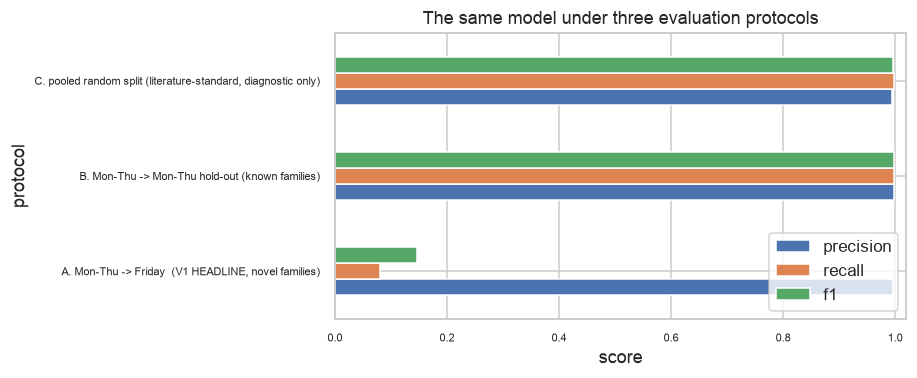

In [83]:
gap = pd.DataFrame([
    {"protocol": "A. Mon-Thu -> Friday  (V1 HEADLINE, novel families)",
     **{k: test_primary[k] for k in ("precision", "recall", "f1", "pr_auc")}},
    {"protocol": "B. Mon-Thu -> Mon-Thu hold-out (known families)",
     **{k: val_final_primary[k] for k in ("precision", "recall", "f1", "pr_auc")}},
    {"protocol": "C. pooled random split (literature-standard, diagnostic only)",
     **{k: m_abl[k] for k in ("precision", "recall", "f1", "pr_auc")}},
])
print(gap.round(5).to_string(index=False))

fig, ax = plt.subplots(figsize=(8.5, 3.6))
gap.set_index("protocol")[["precision", "recall", "f1"]].plot(kind="barh", ax=ax)
ax.set_xlim(0, 1.02); ax.set_xlabel("score")
ax.set_title("The same model under three evaluation protocols")
ax.tick_params(labelsize=7); plt.tight_layout(); plt.show()

### Conclusion of the ablation

The identical schema, preprocessing and forest score near-ceiling under protocol **C** and under
protocol **B**, and poorly on recall under protocol **A**. The pipeline is therefore sound; the
Section-14 result is a measurement of **novel-attack-family generalisation**, which is a genuinely
hard, open problem — not evidence of a broken detector.

This is the honest framing of V1's contribution:

* Against attack families it has been trained on, the detector is strong and its false-positive
  rate is low enough to be operable (protocols B and C).
* Against families it has never seen, a per-flow misuse detector is weak, and this notebook
  measures exactly how weak rather than hiding it behind a pooled random split.
* The V2 roadmap follows directly from the measurement: broaden family coverage in training, add a
  novelty channel, and add cross-flow temporal features.

No claim is made that this system outperforms existing IDS products. The claim is narrower and
defensible: on this benchmark, under a stated protocol, these are the numbers, and here is why they
are what they are.